# <a id='toc1_'></a>[Auswertungen: kolorektale Krebserkrankungen](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Auswertungen: kolorektale Krebserkrankungen](#toc1_)    
  - [📆 Datenstand](#toc1_1_)    
  - [⚙️ Teildatensatz](#toc1_2_)    
  - [Fallzahlen](#toc1_3_)    
    - [Teildatensatz](#toc1_3_1_)    
    - [Fallzahlen C18-C20 in Verhältnis zu allen Diagnosen](#toc1_3_2_)    
    - [Fallzahlen C18-C20 nach Viersteller](#toc1_3_3_)    
  - [OP](#toc1_4_)    
    - [Operation erfolgt bei C18 mit T_p > 0](#toc1_4_1_)    
    - [Operation erfolgt nach Jahren](#toc1_4_2_)    
  - [OPS](#toc1_5_)    
    - [OPS 5-4xx nach Diagnose](#toc1_5_1_)    
    - [ Verteilung OPS 5-455 bei C18](#toc1_5_2_)    
    - [ Verteilung OPS 5-484 bei C20](#toc1_5_3_)    
    - [Details OPS 5-455.2](#toc1_5_4_)    
      - [Ileozökalresektion](#toc1_5_4_1_)    
      - [rechte Hemikolektomie](#toc1_5_4_2_)    
      - [Sigmaresektion](#toc1_5_4_3_)    
  - [Lokalisation (Fernmetastasen)](#toc1_6_)    
    - [für M1](#toc1_6_1_)    
  - [Rezidive](#toc1_7_)    
    - [Verteilung OP in 2020](#toc1_7_1_)    
      - [davon: Verteilung nur R0](#toc1_7_1_1_)    
  - [Behandlung innerhalb von 6 Wochen](#toc1_8_)    
  - [Erste Behandlung](#toc1_9_)    
    - [Was wurde zuerst behandelt](#toc1_9_1_)    
    - [Zeitlicher Abstand der Behandlungen](#toc1_9_2_)    
  - [Behandlungsverlauf](#toc1_10_)    
  - [🕹️ interaktiv](#toc1_11_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
# # ! update in terminal
# uv add -U --refresh pandas_plots

In [2]:
import os
from pathlib import Path
import pandas as pd
import duckdb as ddb
from connection_helper import sql
from pandas_plots import tbl, pls, hlp
from pandas_plots.hlp import add_bitmask_label
import duckdb as ddb

hlp.show_package_version()
# hlp.show_package_version(["pygwalker", "plotly"])

os.environ["RENDERER"] = "svg"
os.environ['THEME']='light'

dir_db=Path("C://temp") if hlp.get_os(hlp.OperatingSystem.WINDOWS) else Path(os.path.expanduser("~/tmp"))

# file_db_clin = dir_db/'2025-11-11_data_clin.duckdb'
file_db_clin = dir_db/'2026-03-04_data_clin.duckdb'
# file_db_clin = dir_db/'fake_data_clin.duckdb'
if not file_db_clin.exists():
    raise FileNotFoundError(file_db_clin)

if not os.path.exists(".local"):
    os.makedirs(".local")

🐍 3.12.8 | 📦 pandas: 2.3.3 | 📦 numpy: 1.26.4 | 📦 duckdb: 1.4.4 | 📦 pandas-plots: 1.2.12 | 📦 connection-helper: 0.13.3


In [3]:
con = ddb.connect(file_db_clin, read_only=True)
_=con.execute("PRAGMA disable_progress_bar;")

## <a id='toc1_1_'></a>[📆 Datenstand](#toc0_)

In [4]:
sql.print_meta(file_db_clin)

database file:           2026-03-04_data_clin.duckdb
data tag:                v2.4
last kkr data import:    2026-02-26
sql table created:       2026-03-04 10:17:13
doi:                     -
document created:        2026-03-05 16:46:27


## <a id='toc1_2_'></a>[⚙️ Teildatensatz](#toc0_)
- Filter für gültige Fälle: (dieser Filter ist für **alle** Analysen gesetzt)
  - `z_dy` (Diagnosejahr) in 2020-2024
  - `z_icd10_3d` (Primärdiagnose) in `C18`-`C20`

In [5]:
# # * settings
DY_MAX = 2024

# FILTER_DY = f"z_dy between 2020 and {DY_MAX}"
# FILTER_DEFAULT = f"""
#     {FILTER_DY}
# """
# FILTER_COLORECTAL = "z_icd10_3d in ('C18','C19','C20')"

##
FILTERS_DY = (f"z_dy between 2020 and {DY_MAX}", "DJ 2020-2024")
FILTERS_C18C20 = ("z_icd10_3d in ('C18','C19','C20')", "ICD10 C18-C20")
FILTERS_C18 = ("z_icd10_3d in ('C18')", "nur C18")
FILTERS_TP = ("z_t_p_1 in ('1','2','3','4')", "t_p = 1-4")
FILTERS_OPS_5_4 = ("left(Code,3) in ('5-4')", "OPS 5-4")
FILTERS_M0 = ("z_m_pc_1 = '0'", "nur M0")
FILTERS_OP_COUNT = ("z_tum_op_count > 0","> 0 OPS")
FILTERS_OPS = ("""--sql
    (
        left(Code,7) in ('5-455.2', '5-455.4', '5-455.7')
        OR left(Code,5) in ('5-987')
    )""", "OPS 5-4xx | 5-987")

FILTERS_OPS_HEMI = ("""--sql
    (
        left(Code,8) in ('5-455.41', '5-455.45', '5-455.47')
        OR left(Code,5) in ('5-987')
    )""", "OPS hemi")

FILTER_OPS_SIG = ("""--sql
    (
        left(Code,8) in ('5-455.71', '5-455.75', '5-455.77')
        OR left(Code,5) in ('5-987')
    )""", "OPS sigma")

FILTERS_2020 = ("z_dy = 2020", "DJ 2020")
FILTERS_R0 = ("upper(left(Lokale_Beurteilung_Residualstatus,2)) = 'R0'", "Residualstatus R0")
FILTERS_HAS_TREAT = ("""--sql
    ifnull(z_first_treatment,'') <> ''
    and z_first_treatment_after_days >= 0
    """, "Tumore mit Behandlung")



In [6]:
# # ! depr
# * co-li-sy-st
db_treatment_first_co_li_sy_st = (con.sql("""--sql
        -- all tum_id w/ a first_treatment variable that codes the values as bitmask (colon = 1, liver = 2, syst = 4 etc)
        -- do not code a set like "has x but not y" for ops since there are overlaps
        -- use bit operation '&' to filter: WHERE treatment_first_co_li_sy_st & 4 = 4;
        select  z_tum_id, 
            max(colon) + max(liver) * 2 + max(syst) * 4 + max(st) * 8 as treatment_first_co_li_sy_st
        from (
            select 
                tu.z_tum_id,
                case when tu.z_first_treatment = 'op' and z_op_order = 1 and substr(ops.Code,1,5) in ('5-455','5-484','5-485') then 1 else 0 end as colon, 
                case when tu.z_first_treatment = 'op' and z_op_order = 1 and substr(ops.Code,1,5) in ('5-501', '5-502', '5-503') then 1 else 0 end as liver,
                case when tu.z_first_treatment = 'sy' then 1 else 0 end as syst,
                case when tu.z_first_treatment = 'st' then 1 else 0 end as st,
            from Tumor tu 
            left join SYST syst on tu.z_tum_id = syst.z_tum_id
            left join OP op on tu.z_tum_id = op.z_tum_id
            left join OPS ops on op.OPId = ops.OP_TypId
        ) t
        group by z_tum_id
    """)
    .add_bitmask_label(bitmask_col='treatment_first_co_li_sy_st', labels=['co', 'li', 'sy', 'st'], con=con)
    .project("z_tum_id, treatment_first_co_li_sy_st_label as treatment_first_co_li_sy_st")
)

# tbl.descr_db(db_treatment_first_co_li_sy_st, 'treatment_first_co_li_sy_st')

In [7]:
# # # * Leber Gruppen
# db_liver_grps = (con.sql("""--sql
#         select  z_tum_id, 
#             max(g1) + max(g2) * 2 + max(g3) * 4 + max(g4) * 8 + max(g5) * 16 + max(g6) * 32 + max(g7) * 64 + max(g8) * 128 as liver_grps
#         from (
#             select 
#                 tu.z_tum_id,
#                 case when substr(ops.Code,1,8) in ('5-455.21') then 1 else 0 end as g1,
#                 case when substr(ops.Code,1,8) in ('5-455.25') then 1 else 0 end as g2,
#                 case when substr(ops.Code,1,8) in ('5-455.27') then 1 else 0 end as g3,
#                 case when substr(ops.Code,1,8) in ('5-455.31') then 1 else 0 end as g4,
#                 case when substr(ops.Code,1,8) in ('5-455.35') then 1 else 0 end as g5,
#                 case when substr(ops.Code,1,8) in ('5-455.37') then 1 else 0 end as g6,
#                 case when substr(ops.Code,1,8) in ('5-455.41') then 1 else 0 end as g7,
#                 case when substr(ops.Code,1,8) in ('5-455.45') then 1 else 0 end as g8
#             from Tumor tu
#             left join SYST syst on tu.z_tum_id = syst.z_tum_id
#             left join OP op on tu.z_tum_id = op.z_tum_id
#             left join OPS ops on op.OPId = ops.OP_TypId
#         ) t
#         group by z_tum_id
#     """)
#     .add_bitmask_label(bitmask_col='liver_grps', labels=['g21', 'g25', 'g27', 'g31', 'g35', 'g37', 'g41', 'g45'], con=con)
#     .project("z_tum_id, liver_grps_label as liver_grps")
# )
# # tbl.descr_db(db_liver_grps, 'liver_grps')

In [8]:
# con.sql("describe tumor").fetchall()

In [9]:
# # ! depr

# * table id and respective dates (eg. op, st, syst, bestr) are included to give a complete picture of the data
# * first create complete dataset incl all icd10 (>4mio rows) for survey analysis, but reduce to C18C20 after
db_allicd = (con.sql("""--sql
    select 
        tum.z_tum_id,
        tum.z_kkr_label,
        z_icd10, 
        z_icd10_3d,-- icd10_1d,
        z_dy,
        z_sex,
        z_t_p_1, z_t_c_1, z_n_p_1, z_m_pc_1, z_m_p_0,
        coalesce(z_t_p_1, z_t_c_1) as z_t_pc_1,
        uicc.code_1 as UICC_Stadium_p_1,
        z_ag05, 
        z_age,
        --z_tum_st_count, z_tum_op_count, z_tum_sy_count,
        dsich.name as Diagnosesicherung,

        z_pat_id,
        pat.Verstorben,

        op.OPId as op_id, op.Datum_OP,
        z_op_order, dim_op_intention.name as Intention_OP, dim_r_typ.name as OP_Lokale_Beurteilung_Residualstatus,

        syst.SYSTId as syst_id, syst.Datum_Beginn_SYST,
        dim_syst_intention.name as Intention_SYST, syst.Therapieart,
        
        st.STId as st_id, 
        dim_st_intention.name as Intention_ST, dim_st_op_stellung.name as ST_Stellung_OP,

        bestr.BestrahlungId as bestr_id, bestr.Datum_Beginn_Bestrahlung,
        
        folge.FolgeereignisId as folge_id, folge.Datum_Folgeereignis,
        dim_verlauf_lokal.name as Folge_Verlauf_Lokaler_Tumorstatus,

        dim_fm_lokalisation.name as FM_Lokalisation,
        
        RASMutation,
        RektumAbstandAnokutanlinie,

        z_first_treatment, 
        z_first_treatment_after_days,
        z_tum_st_count, z_tum_op_count, z_tum_sy_count, z_tum_fo_count,
        (z_tum_op_count > 0) as tum_has_op,
        db_treatment_first_co_li_sy_st.treatment_first_co_li_sy_st,
        --db_liver_grps.liver_grps,
        z_last_tum_status,

        case when z_icd10_3d in ('C18','C19','C20') then cast(true as bool) else cast(false as bool) end as 'C18C20',
    from Tumor tum
    join Patient pat on tum.oBDS_RKIPatientId = pat.oBDS_RKIPatientId
    left join db_treatment_first_co_li_sy_st on tum.z_tum_id = db_treatment_first_co_li_sy_st.z_tum_id
    --left join db_liver_grps on tum.z_tum_id = db_liver_grps.z_tum_id
    left join dim_diagnosesicherung_clin dsich on dsich.code = Diagnosesicherung
    left join SYST syst on tum.z_tum_id = syst.z_tum_id
    left join ST st on tum.z_tum_id = st.z_tum_id
    left join Bestrahlung bestr on st.STId = bestr.STId
    left join OP op on tum.z_tum_id = op.z_tum_id
    left join dim_tnm_uicc uicc on UICC_Stadium_p = uicc.code
    left join Folgeereignis folge on tum.z_tum_id = folge.z_tum_id
    left join Diagnose_Fernmetastase fm on tum.z_tum_id = fm.z_tum_id
    left join dim_beurteilung_gesamt dim_folge_1 on Gesamtbeurteilung_Tumorstatus = dim_folge_1.code
    left join dim_fm_lokalisation on Lokalisation = dim_fm_lokalisation.code
    left join dim_verlauf_lokal on folge.Verlauf_Lokaler_Tumorstatus = dim_verlauf_lokal.code
    left join dim_op_intention on op.Intention = dim_op_intention.code
    left join dim_st_intention on st.Intention = dim_st_intention.code
    left join dim_st_op_stellung on st.Stellung_OP = dim_st_op_stellung.code
    left join dim_syst_intention on syst.Intention = dim_syst_intention.code
    left join dim_r_typ on op.Lokale_Beurteilung_Residualstatus = dim_r_typ.code
    """)
    .filter(f"{FILTERS_DY[0]}")
)

# * derive colorectal dataset
db_colon = db_allicd.filter(f"{FILTERS_C18C20[0]}")

# tbl.descr_db(db_allicd, caption="all icd", use_preview=False)
# tbl.descr_db(db_colon, caption="colorectal", use_preview=True)

<!-- ### <a id='toc1_2_1_'></a>[Deskriptive Statistik](#toc0_) -->

## <a id='toc1_3_'></a>[Fallzahlen](#toc0_)

In [10]:
_filters = [
    FILTERS_DY,
    FILTERS_C18C20,
]
filter_default = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters,
    # distinct_metric="z_tum_id",
)


<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 4_015_983                    (100.0%) ██████████████████████████████
└ [DJ 2020-2024]:  n = 3_758_513  (93.6%) ░░████████████████████████████
└ [ICD10 C18-C20]:   n = 284_931   (7.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18','C19','C20')
```

</details>

### <a id='toc1_3_3_'></a>[Fallzahlen C18-C20 nach Viersteller](#toc0_)
- Filter: `C18-20`
> 💡 `C19` darf eigentlich nicht verwendet werden, wird von Krebsgesellschaft nicht akzeptiert

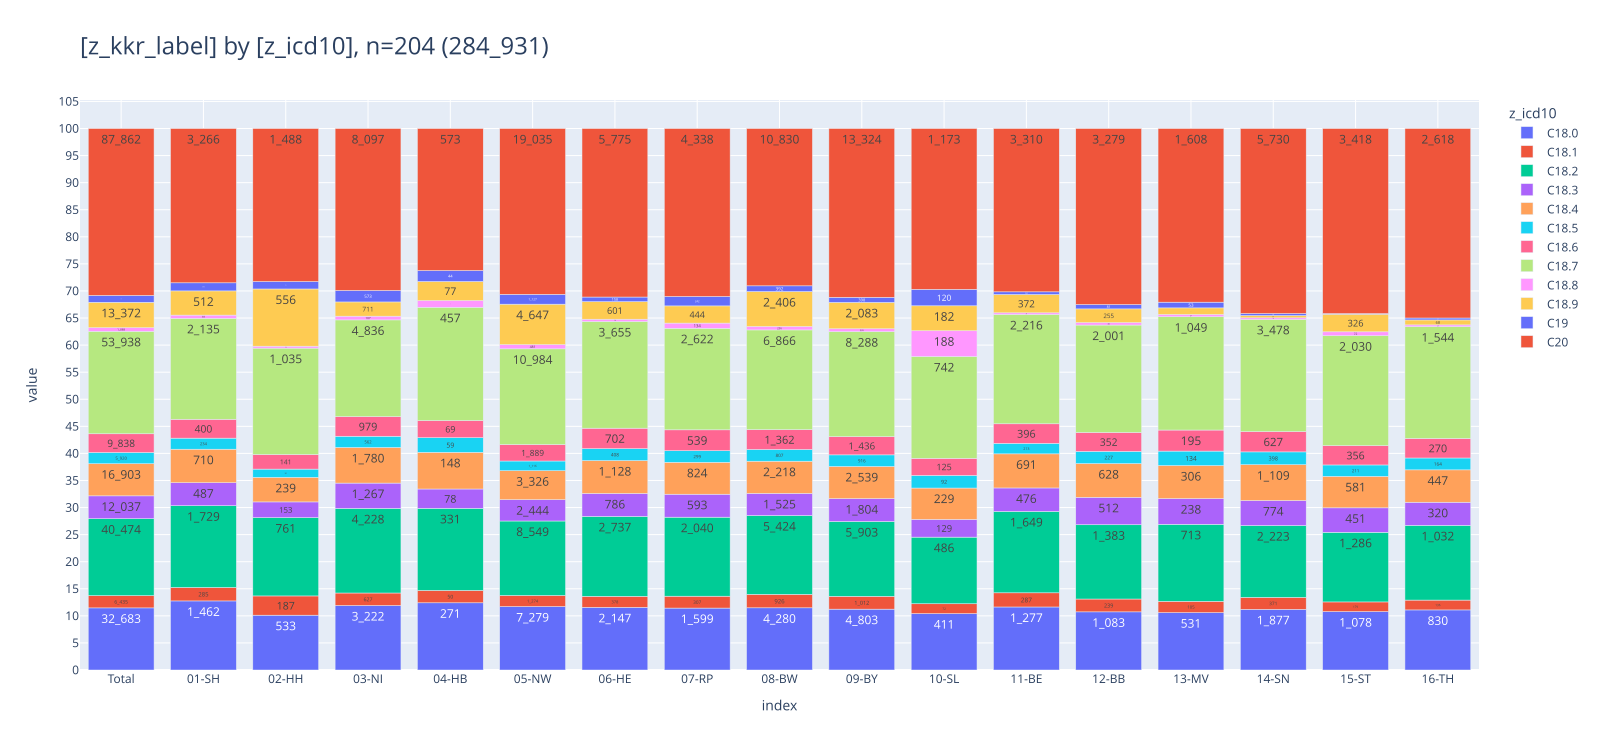

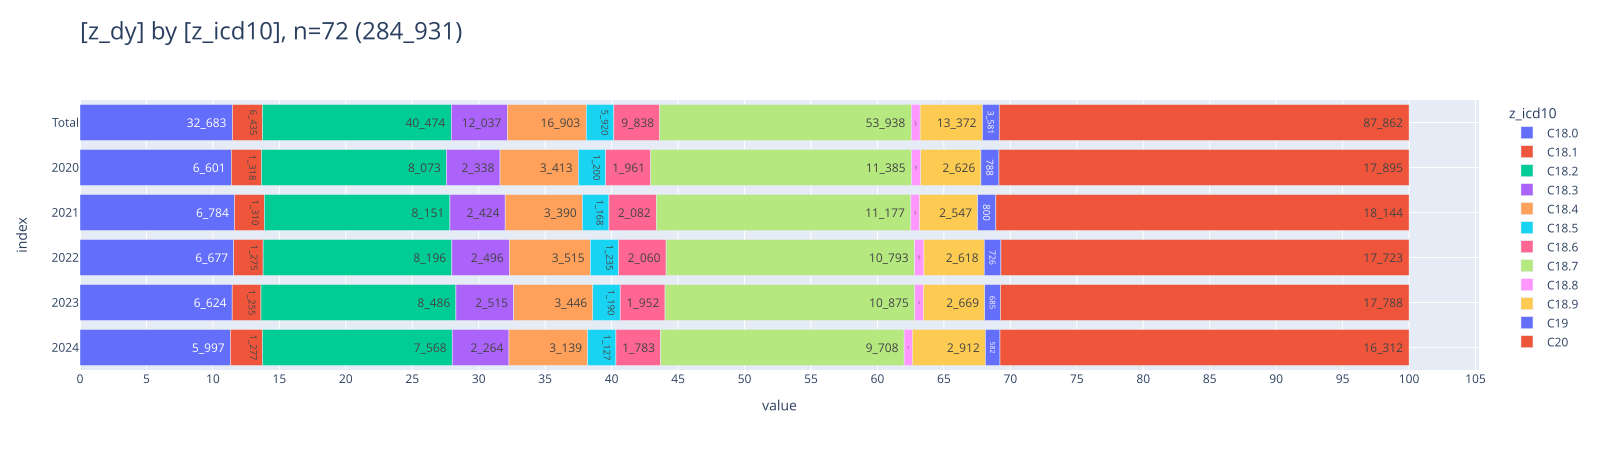

In [11]:
_df = con.sql(f"""--sql
    select
        z_dy::text as z_dy,
        z_kkr_label,
        z_icd10,
    from Tumor
    where {filter_default}
""").to_df()

_=pls.plot_stacked_bars(_df[["z_kkr_label", "z_icd10"]], orientation="v", height=750, show_total=True, relative=True)
_=pls.plot_stacked_bars(_df[["z_dy", "z_icd10"]], orientation="h", height=450, show_total=True, relative=True)


## <a id='toc1_4_'></a>[OP](#toc0_)

### <a id='toc1_4_1_'></a>[Operation erfolgt bei C18 mit T_p > 0](#toc0_)
- Filter: `C18` und pathologisches T in 1-4
> 💡 5% wäre realistisch. patho stadium müsste zwingend vorhanden sein nach OP

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 4_015_983
└ [DJ 2020-2024]:  n = 3_758_513
└ [ICD10 C18-C20]: n = 284_931 (100.0%) ██████████████████████████████
└ [nur C18]:       n = 193_488  (67.9%) ░░░░░░░░░░████████████████████
└ [t_p = 1-4]:     n = 150_961  (53.0%) ░░░░░░░░░░░░░░░███████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18','C19','C20')
and z_icd10_3d in ('C18')
and z_t_p_1 in ('1','2','3','4')
```

</details>

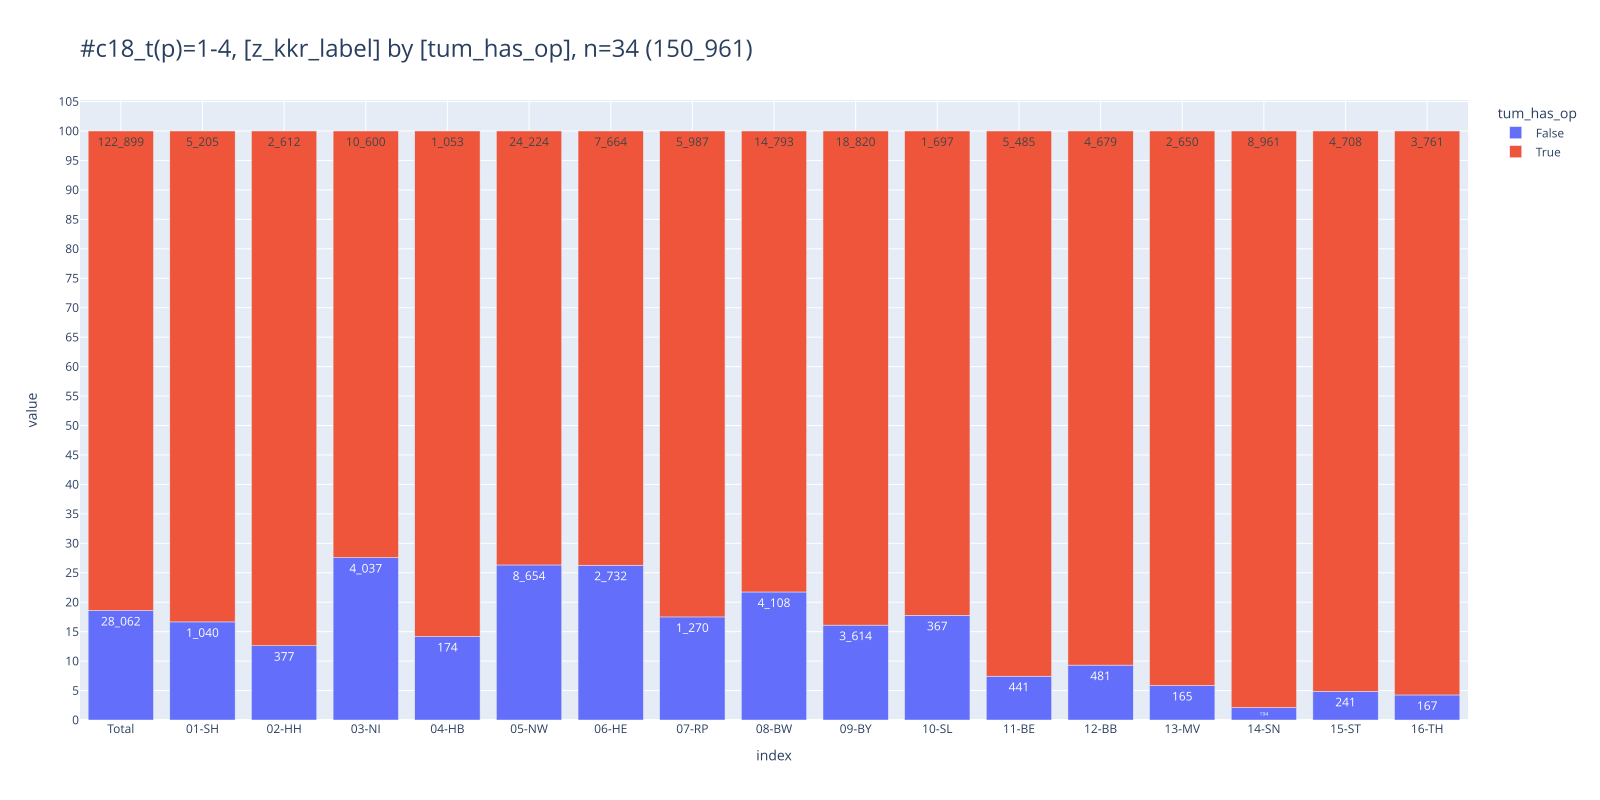

In [12]:

_filters_op = [
    FILTERS_DY,
    FILTERS_C18C20,
    FILTERS_C18,
    FILTERS_TP,
]
_filter_op = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters_op,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=2,
)


df = (
    db_colon
    .filter(_filter_op)
    .aggregate("z_kkr_label, tum_has_op, count(distinct z_tum_id) as cnt_tum")
    .to_df()
)
_=pls.plot_stacked_bars(
    df,
    relative=True,
    show_total=True,
    orientation="v",
    height=800,
    caption="c18_t(p)=1-4",
)
# tbl.pivot_df(df, data_bar_axis="xy", pct_axis="xy", swap=True)

### <a id='toc1_4_2_'></a>[Operation erfolgt nach Jahren](#toc0_)
- Filter: `C18` und pathologisches T in 1-4
- `categ_treat`
  - `1-op` - OP dokumentiert
  - `2-noop-sy-st` - keine OP dokumentiert, aber ST oder SYST
  - `3-noop-nosy-nost` - keine Behandlung dokumentiert

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 4_015_983
└ [DJ 2020-2024]:  n = 3_758_513
└ [ICD10 C18-C20]: n = 284_931 (100.0%) ██████████████████████████████
└ [nur C18]:       n = 193_488  (67.9%) ░░░░░░░░░░████████████████████
└ [t_p = 1-4]:     n = 150_961  (53.0%) ░░░░░░░░░░░░░░░███████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18','C19','C20')
and z_icd10_3d in ('C18')
and z_t_p_1 in ('1','2','3','4')
```

</details>

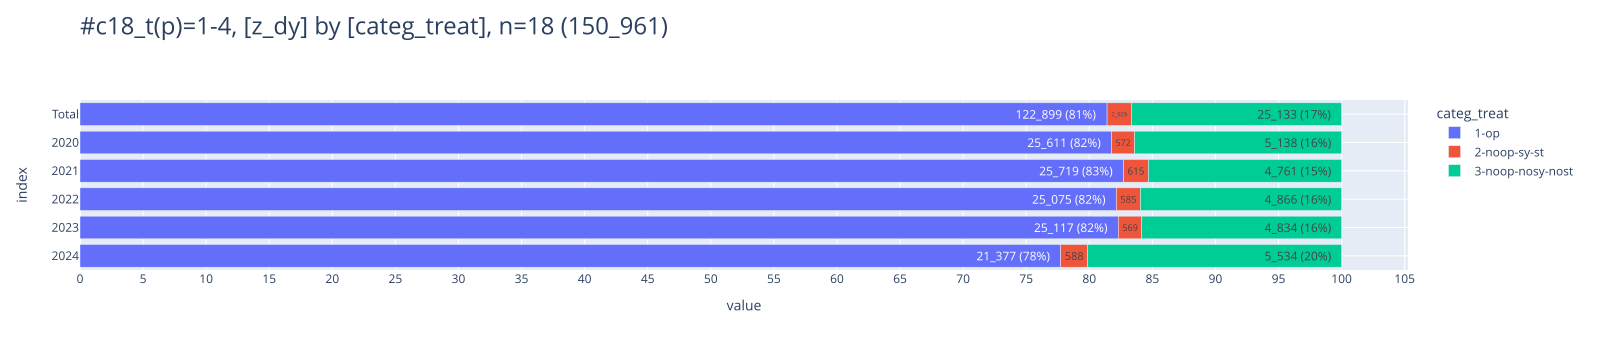

In [13]:
_filters_op = [
    FILTERS_DY,
    FILTERS_C18C20,
    FILTERS_C18,
    FILTERS_TP,
]
_filter_op = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters_op,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=2,
)

df = (db_colon
    .filter(_filter_op)
    .project("""--sql
            *,
            case 
                when tum_has_op then '1-op' 
                when not tum_has_op and z_tum_sy_count > 0 or z_tum_st_count > 0 then '2-noop-sy-st' 
                when not tum_has_op and z_tum_sy_count = 0 and z_tum_st_count = 0 then '3-noop-nosy-nost' 
                else '9-unknown' end as categ_treat
    """)
    .aggregate("z_dy::text as z_dy, categ_treat, count(distinct z_tum_id) as cnt_tum")
    .to_df()
)
_=pls.plot_stacked_bars(
    df,
    relative=True,
    show_total=True,
    orientation="h",
    height=350,
    show_pct_bar=True,
    caption="c18_t(p)=1-4",
)

## <a id='toc1_5_'></a>[OPS](#toc0_)


### <a id='toc1_5_1_'></a>[OPS 5-4xx nach Diagnose](#toc0_)
- Filter: `C18-C20`
- gezählt sind OPS Angaben, nicht Tumore

<br>

In [14]:
def show_ops(filter: str, caption: str,):
    db_ops_kkr = con.sql(f"""--sql
        select
                z_dy::text as z_dy,
                z_kkr_label,
                ops.Code as ops_code,
                count(distinct OPSId) as cnt_ops,
                dim_ops.name as ops_name,
        from Tumor tum
        left join OP op on tum.z_tum_id = op.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        left join (select code as code_, name from dim_ops) as dim_ops on dim_ops.code_ = ops.Code
        where {filter}
        group by ops_code, z_kkr_label, ops_name, z_dy
        """)
    # tbl.descr_db(db_ops_kkr, "ops_kk")

    # if print_table:
    print("Anzahl verschiedene ops_codes: ",db_ops_kkr.count("distinct ops_code").fetchone()[0])
    db_ops_kkr.aggregate("ops_code || ' - ' || ops_name as ops, sum(cnt_ops)::int as cnt_ops").order("cnt_ops desc").limit(10).show(max_width=145)
    
    # hlp.print_filter(filter, show_as_details=True)

    display(_ = pls.plot_stacked_bars(
        db_ops_kkr.project("z_kkr_label, ops_code, cnt_ops").to_df(),
        # orientation="h",
        relative=True,
        top_n_color=10,
        sort_values_color=True,
        caption=caption,
    ))
    display(_ = pls.plot_stacked_bars(
        db_ops_kkr.project("z_dy, ops_code, cnt_ops").to_df(),
        orientation="h",
        relative=True,
        height=400,
        top_n_color=10,
        sort_values_color=True,
        caption=caption,
    ))

<!-- START_TOKEN -->

counts: distinct OPSId
---
n = 4_039_783                    (100.0%) ██████████████████████████████
└ [DJ 2020-2024]:  n = 3_990_198  (98.8%) ░█████████████████████████████
└ [ICD10 C18-C20]:   n = 499_943  (12.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░███
└ [nur C18]:         n = 324_504   (8.0%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██
└ [OPS 5-4]:         n = 218_360   (5.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18','C19','C20')
and z_icd10_3d in ('C18')
and left(Code,3) in ('5-4')
```

</details>

Anzahl verschiedene ops_codes:  17902
┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┐
│                                                                 ops                                                                 │ cnt_ops │
│                                                               varchar                                                               │  int32  │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼─────────┤
│ 5-455.41 - Partielle Resektion des Dickdarmes: Resektion des Colon ascendens mit Coecum und rechter Flexur [Hemikolektomie rechts…  │   30629 │
│ 5-455.45 - Partielle Resektion des Dickdarmes: Resektion des Colon ascendens mit Coecum und rechter Flexur [Hemikolektomie rechts…  │   21351 │
│ 5-469.20 - Andere Operationen am Darm: Adhäsiolyse: Offen chirurgisch               

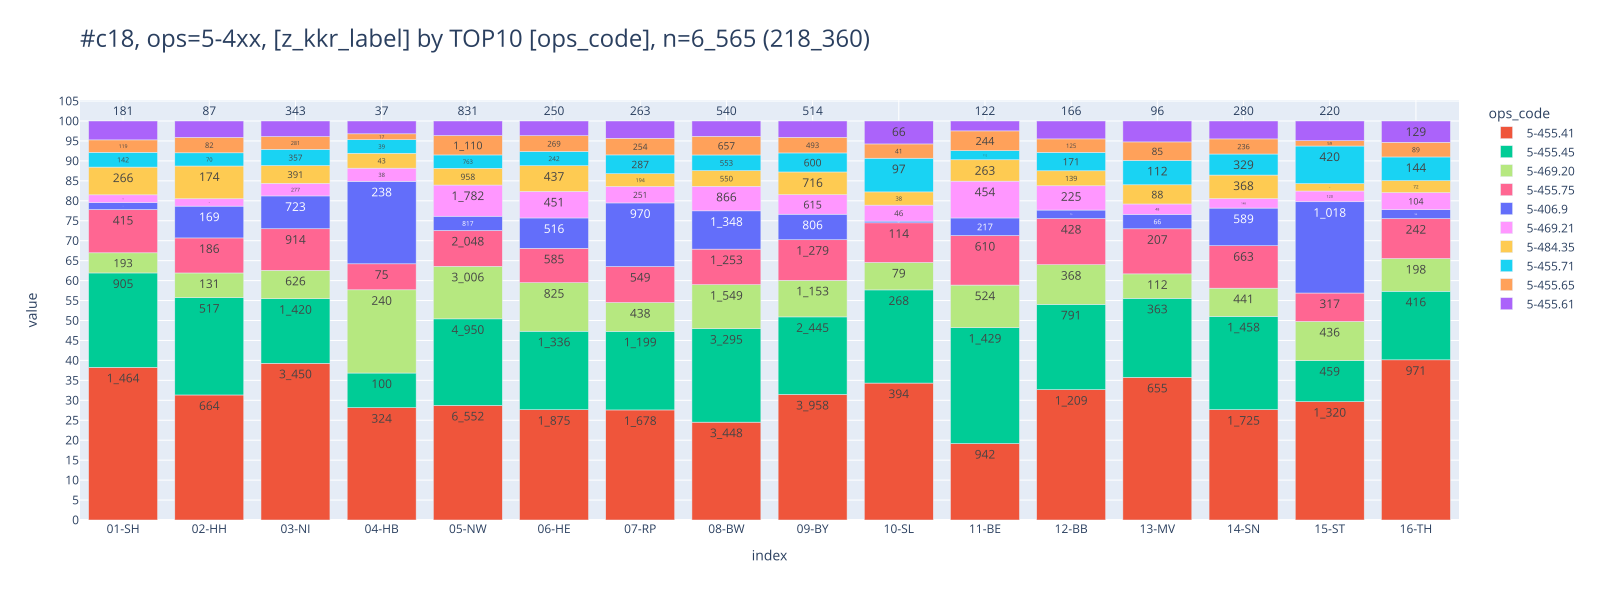

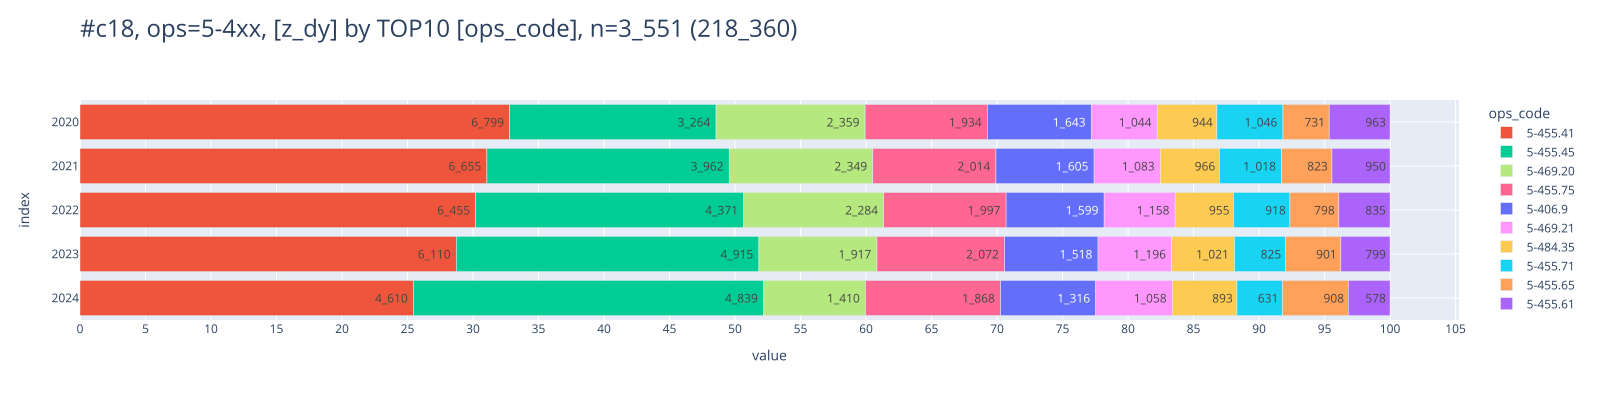

In [15]:
_filters_ops1 = [
    FILTERS_DY,
    FILTERS_C18C20,
    FILTERS_C18,
    FILTERS_OPS_5_4,
]
_filter_ops1 = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor tum left join OPS ops on tum.z_tum_id = ops.z_tum_id",
    # query="from Tumor tum left join OP op on tum.z_tum_id = op.z_tum_id left join OPS ops on op.OPId = ops.OP_TypId",
    filters=_filters_ops1,
    distinct_metric="OPSId",
    first_n_filter_apply_to_rows=0,
)

show_ops(_filter_ops1,"c18, ops=5-4xx")

<!-- START_TOKEN -->

counts: distinct OPSId
---
n = 4_039_783                    (100.0%) ██████████████████████████████
└ [DJ 2020-2024]:  n = 3_990_198  (98.8%) ░█████████████████████████████
└ [ICD10 C18-C20]:   n = 499_943  (12.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░███
└ [ICD10 C19]:         n = 4_223   (0.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
└ [OPS 5-4]:           n = 2_847   (0.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18','C19','C20')
and z_icd10_3d in ('C19')
and left(Code,3) in ('5-4')
```

</details>

Anzahl verschiedene ops_codes:  1489
┌────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┐
│                                                                ops                                                                 │ cnt_ops │
│                                                              varchar                                                               │  int32  │
├────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼─────────┤
│ 5-484.35 - Rektumresektion unter Sphinktererhaltung: Anteriore Resektion: Laparoskopisch mit Anastomose                            │     427 │
│ 5-484.31 - Rektumresektion unter Sphinktererhaltung: Anteriore Resektion: Offen chirurgisch mit Anastomose                         │     162 │
│ 5-484.55 - Rektumresektion unter Sphinktererhaltung: Tiefe anteriore Resektion: Laparoskopi

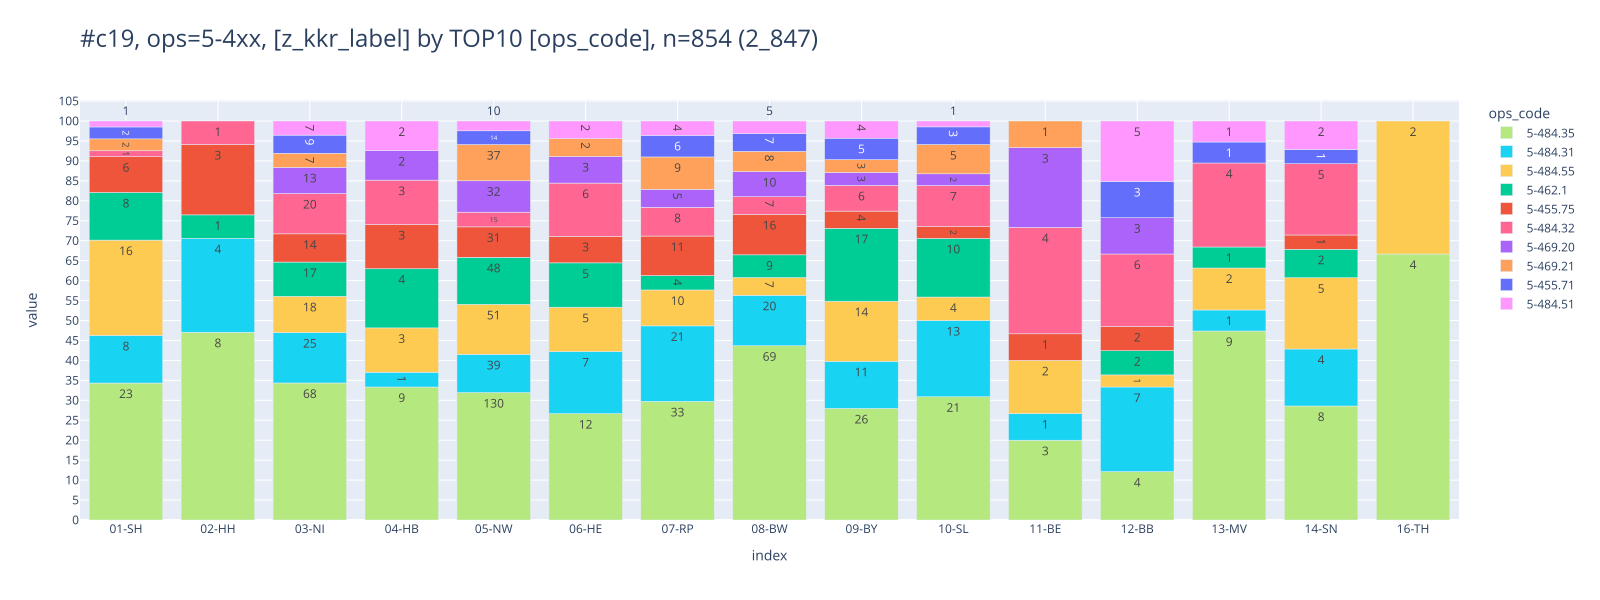

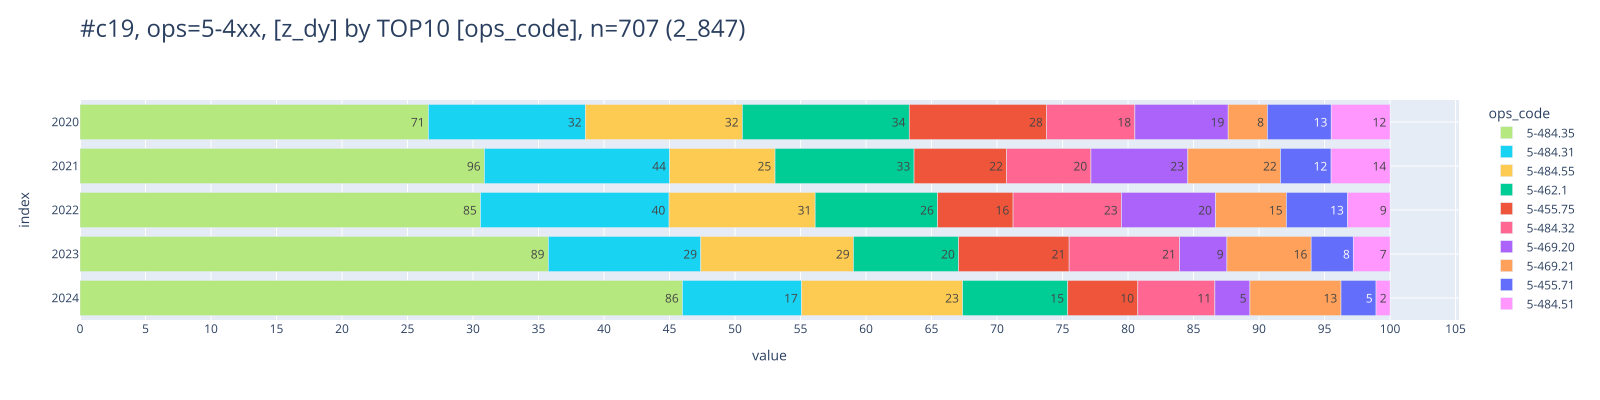

In [16]:
_filters_ops2 = [
    FILTERS_DY,
    FILTERS_C18C20,
    ("z_icd10_3d in ('C19')", "ICD10 C19"),
    FILTERS_OPS_5_4,
]
_filter_ops2 = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor tum left join OPS ops on tum.z_tum_id = ops.z_tum_id",
    # query="from Tumor tum left join OP op on tum.z_tum_id = op.z_tum_id left join OPS ops on op.OPId = ops.OP_TypId",
    filters=_filters_ops2,
    distinct_metric="OPSId",
    first_n_filter_apply_to_rows=0,
)

show_ops(_filter_ops2, "c19, ops=5-4xx")

<!-- START_TOKEN -->

counts: distinct OPSId
---
n = 4_039_783                    (100.0%) ██████████████████████████████
└ [DJ 2020-2024]:  n = 3_990_198  (98.8%) ░█████████████████████████████
└ [ICD10 C18-C20]:   n = 499_943  (12.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░███
└ [ICD10 C20]:       n = 171_216   (4.2%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█
└ [OPS 5-4]:         n = 111_428   (2.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18','C19','C20')
and z_icd10_3d in ('C20')
and left(Code,3) in ('5-4')
```

</details>

Anzahl verschiedene ops_codes:  13205
┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────┐
│                                                                 ops                                                                 │ cnt_ops │
│                                                               varchar                                                               │  int32  │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼─────────┤
│ 5-484.55 - Rektumresektion unter Sphinktererhaltung: Tiefe anteriore Resektion: Laparoskopisch mit Anastomose                       │   12559 │
│ 5-462.1 - Anlegen eines Enterostomas (als protektive Maßnahme) im Rahmen eines anderen Eingriffs: Ileostoma                         │   12076 │
│ 5-484.35 - Rektumresektion unter Sphinktererhaltung: Anteriore Resektion: Laparoskop

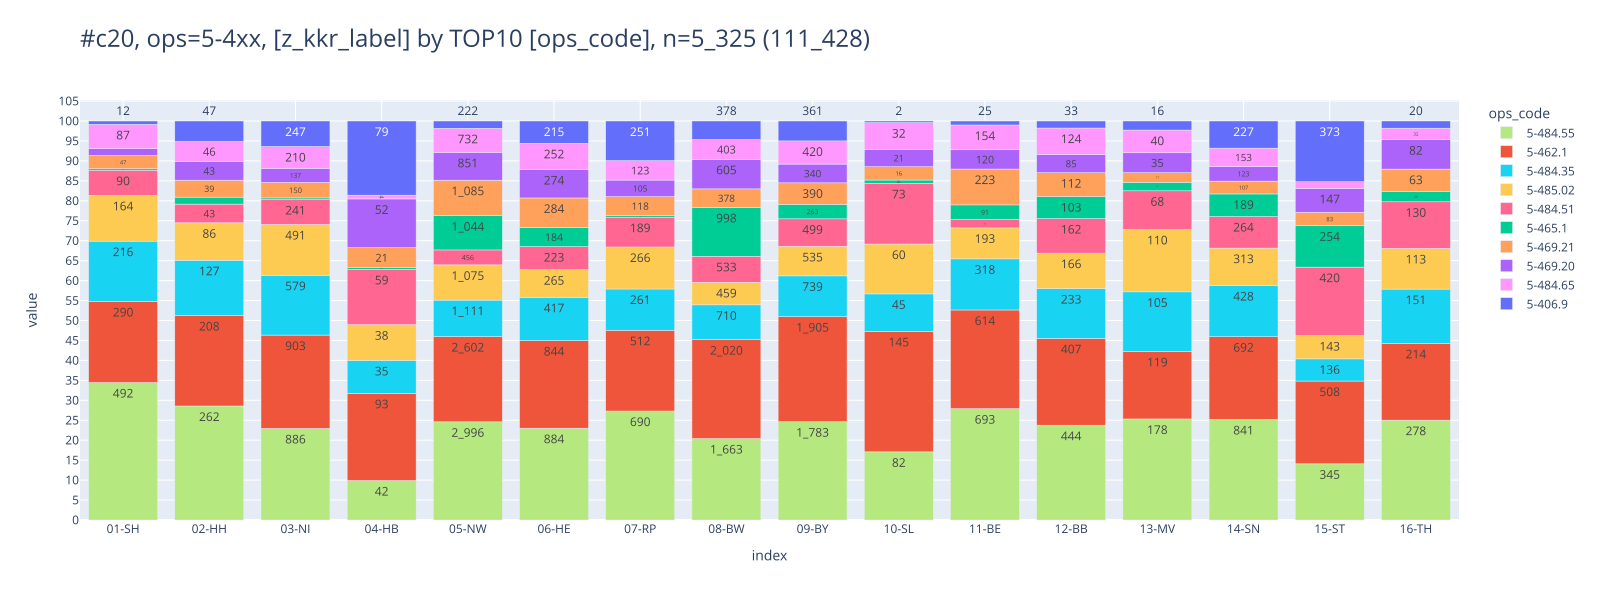

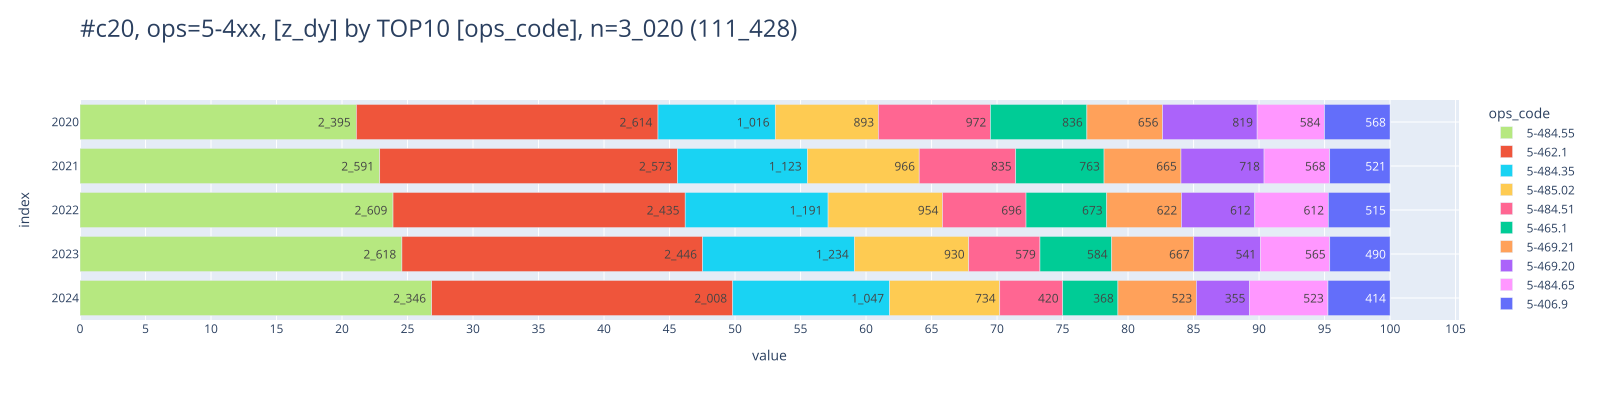

In [17]:
_filters_ops3 = [
    FILTERS_DY,
    FILTERS_C18C20,
    ("z_icd10_3d in ('C20')", "ICD10 C20"),
    FILTERS_OPS_5_4,
]
_filter_ops3 = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor tum left join OPS ops on tum.z_tum_id = ops.z_tum_id",
    # query="from Tumor tum left join OP op on tum.z_tum_id = op.z_tum_id left join OPS ops on op.OPId = ops.OP_TypId",
    filters=_filters_ops3,
    distinct_metric="OPSId",
    first_n_filter_apply_to_rows=0,
)

show_ops(_filter_ops3, "c20, ops=5-4xx")

### <a id='toc1_5_2_'></a>[ Verteilung OPS 5-455 bei C18](#toc0_)
- Filter: `C18` und `M0`
- gezählt sind Tumore
- `has_5-455`: True wenn Tumor >= 1 OPS 5-455 hat
> 💡 Erwartet sind ~95% Anteil für True, tatsächlich sind es für D ~75%

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 4_015_983
└ [DJ 2020-2024]:  n = 3_758_513
└ [ICD10 C18-C20]: n = 284_931 (100.0%) ██████████████████████████████
└ [nur C18]:       n = 193_488  (67.9%) ░░░░░░░░░░████████████████████
└ [nur M0]:        n = 113_713  (39.9%) ░░░░░░░░░░░░░░░░░░░███████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18','C19','C20')
and z_icd10_3d in ('C18')
and z_m_pc_1 = '0'
```

</details>

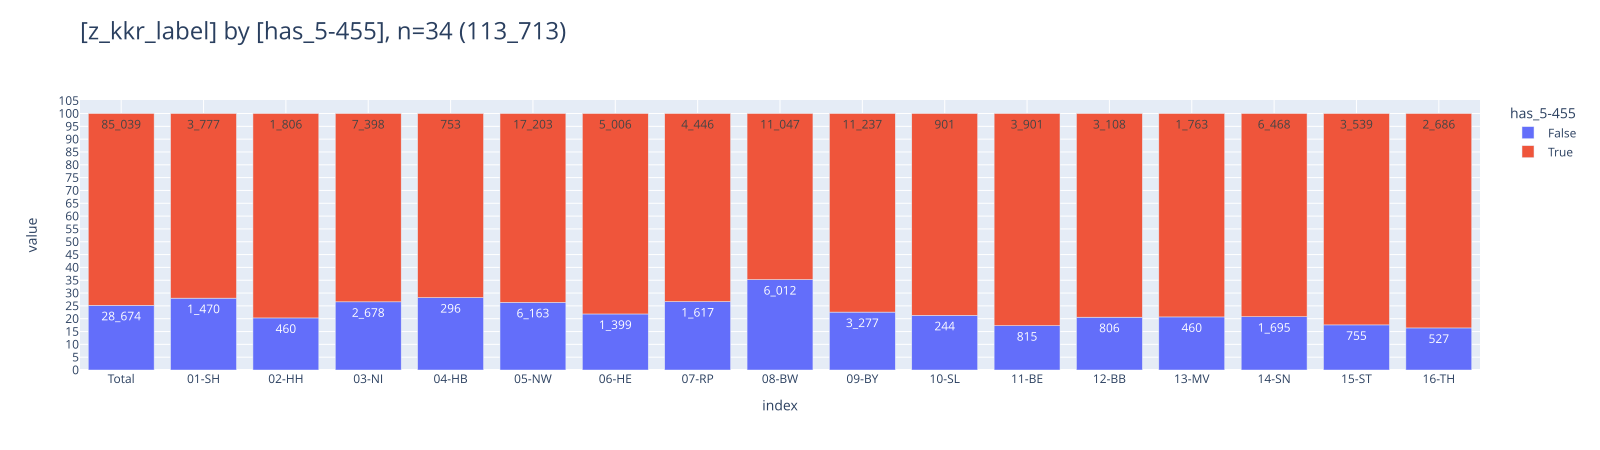

In [18]:
_filters_ops_5455 = [
    FILTERS_DY,
    FILTERS_C18C20,
    FILTERS_C18,
    FILTERS_M0,
]
_filter_ops_5455 = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters_ops_5455,
    # distinct_metric="OPSId",
    first_n_filter_apply_to_rows=2,
)

_df = (con.sql(f"""--sql
        SELECT  tum.z_tum_id,
                tum.z_kkr_label, 
                max((substr(ifnull(ops.Code,''),1,5) = '5-455')) as 'has_5-455',
        FROM (select * from Tumor where {_filter_ops_5455}) tum
        LEFT JOIN OP op ON tum.z_tum_id = op.z_tum_id
        LEFT JOIN OPS ops ON op.OPId = ops.OP_TypId
        group by tum.z_tum_id, tum.z_kkr_label
        """)
    .project("* exclude (z_tum_id)")
    .to_df()
)
_=pls.plot_stacked_bars(_df, relative=True, show_total=True, orientation="v", height=450)

### <a id='toc1_5_3_'></a>[ Verteilung OPS 5-484 bei C20](#toc0_)
- Filter: `C18` und `M0`
- `has_5-48x`: True wenn Tumor >= 1 OPS 5-484 oder 5-485 hat
> 💡 ~40% haben True, weniger als erwartet 

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 4_015_983
└ [DJ 2020-2024]:  n = 3_758_513
└ [ICD10 C18-C20]: n = 284_931 (100.0%) ██████████████████████████████
└ [ICD10 C20]:      n = 87_862  (30.8%) ░░░░░░░░░░░░░░░░░░░░░█████████
└ [nur M0]:         n = 52_446  (18.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░█████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18','C19','C20')
and z_icd10_3d in ('C20')
and z_m_pc_1 = '0'
```

</details>

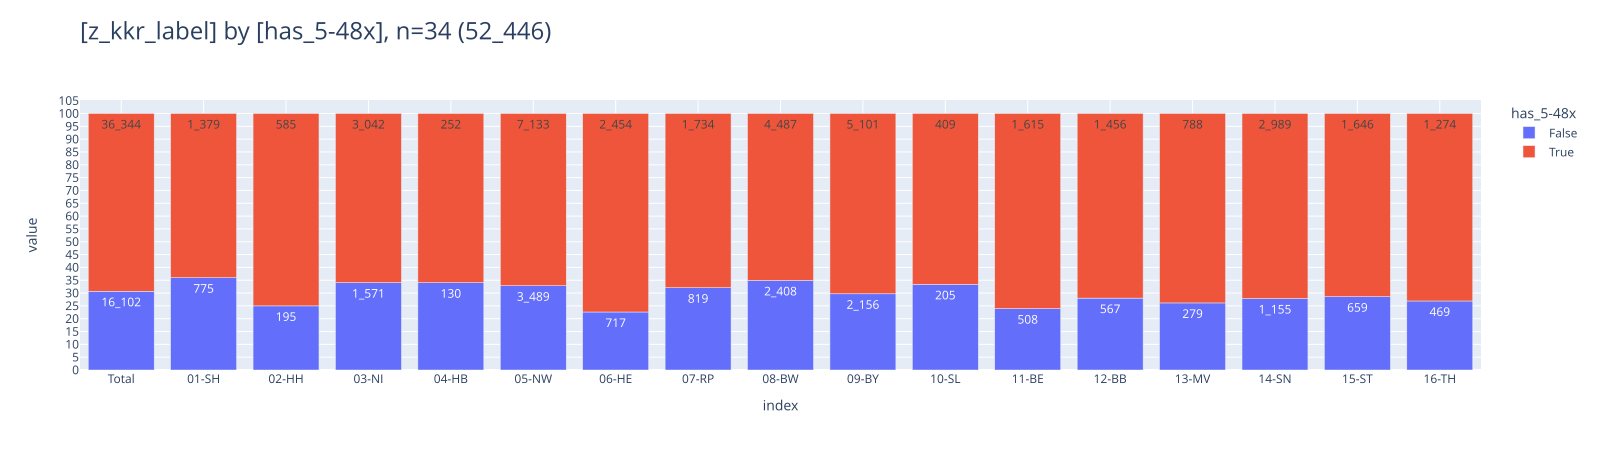

In [19]:
_filters_ops_5484 = [
    FILTERS_DY,
    FILTERS_C18C20,
    ("z_icd10_3d in ('C20')", "ICD10 C20"),
    FILTERS_M0,
]
_filter_ops_5484 = hlp.get_duckdb_filter_n(
    con=con,
    query="from Tumor",
    filters=_filters_ops_5484,
    # distinct_metric="OPSId",
    first_n_filter_apply_to_rows=2,
)

df = (con.sql(f"""--sql
        SELECT  tum.z_tum_id,
                tum.z_kkr_label, 
                max((substr(ifnull(ops.Code,''),1,5) in ('5-484', '5-485'))) as 'has_5-48x',
        FROM (select * from Tumor where {_filter_ops_5484}) tum
        LEFT JOIN OP op ON tum.z_tum_id = op.z_tum_id
        LEFT JOIN OPS ops ON op.OPId = ops.OP_TypId
        group by tum.z_tum_id, tum.z_kkr_label
        """)
    .project("* exclude (z_tum_id)")
    .to_df()
    
)
_=pls.plot_stacked_bars(df, relative=True, show_total=True, orientation="v", height=450)

### <a id='toc1_5_4_'></a>[Details OPS 5-455.2](#toc0_)
- Filter: `C18-C20`, alle Tumore mit min 1 OP
- gezählt sind Tumore / OPS
- die Gruppen können überlappen bei der Tumordarstellung
  - `lleo` - Ileozökalresektion
  - `hemi` - rechte Hemikolektomie
  - `sigma` - Sigmaresektion
- in allen Darstellungen ist Robotik ebenfalls angegeben (`5-987`) bzw `5-987.01`
  <!-- - `-` - keine der genannten OPS -->

<!-- START_TOKEN -->

counts: distinct z_tum_id
---
n = 4_015_983
└ [DJ 2020-2024]:      n = 3_758_513
└ [ICD10 C18-C20]:     n = 284_931 (100.0%) ██████████████████████████████
└ [> 0 OPS]:           n = 185_576  (65.1%) ░░░░░░░░░░░███████████████████
└ [OPS 5-4xx | 5-987]:  n = 90_227  (31.7%) ░░░░░░░░░░░░░░░░░░░░░█████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18','C19','C20')
and z_tum_op_count > 0
and 
    (
        left(Code,7) in ('5-455.2', '5-455.4', '5-455.7')
        OR left(Code,5) in ('5-987')
    )
```

</details>

n = 90_227 | n(true) = 90_227


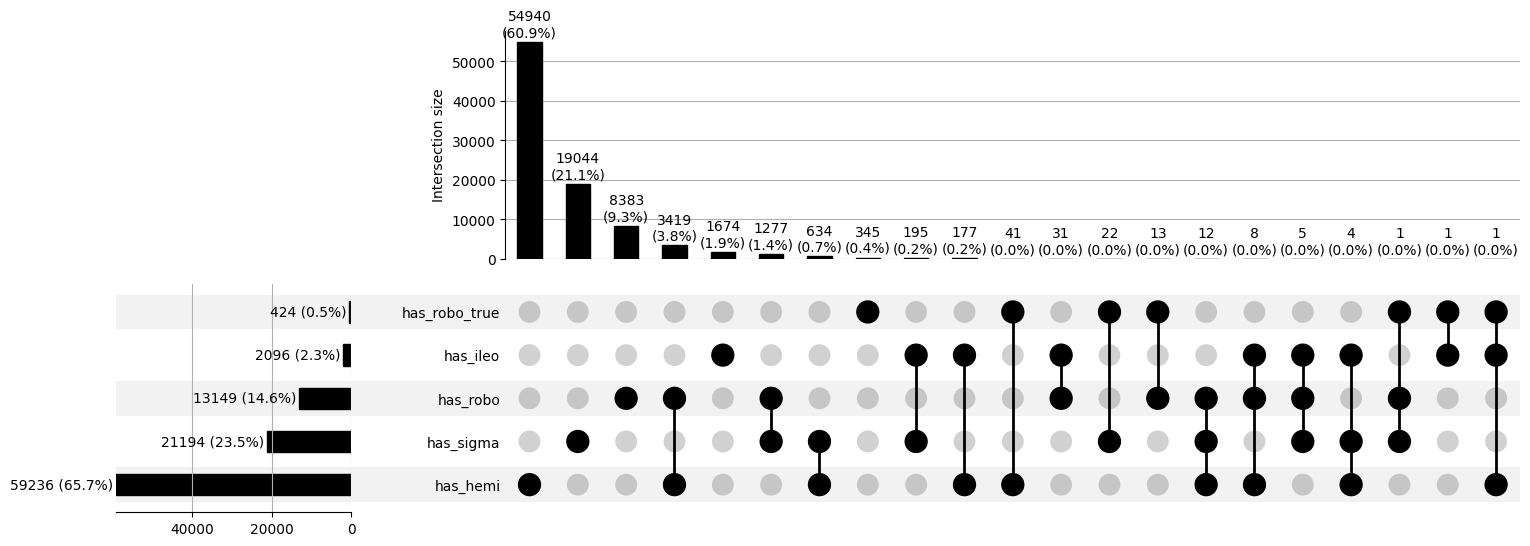

In [20]:
_filters_ops5 = [
    FILTERS_DY,
    FILTERS_C18C20,
    FILTERS_OP_COUNT,
    FILTERS_OPS,
]

_filter_ops5=hlp.get_duckdb_filter_n(
    con=con,
    query="""--sql
        from Tumor tum
        left join OPS ops on tum.z_tum_id = ops.z_tum_id
        """,
    filters=_filters_ops5,
    first_n_filter_apply_to_rows=2,
    distinct_metric="z_tum_id",
)

db_ops_upset = con.sql(f"""--sql
    with t1 as (
        select
            tu.z_tum_id,
            z_kkr_label,
            case when left(ops.Code,7) in ('5-455.2') then true else false end as ileo,
            case when left(ops.Code,7) in ('5-455.4') then true else false end as hemi,
            case when left(ops.Code,7) in ('5-455.7') then true else false end as sigma,
            case when left(ops.Code,8) in ('5-987.01') then true else false end as robo_true,
            case when left(ops.Code,5) in ('5-987') and not robo_true then true else false end as robo,
        from Tumor tu
        left join OP op on tu.z_tum_id = op.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        where {_filter_ops5}
    ), t2 as (
        select
            z_tum_id,
            max(ileo) as has_ileo,
            max(hemi) as has_hemi,
            max(sigma) as has_sigma,
            max(robo_true) as has_robo_true,
            max(robo) as has_robo,
        from t1
        group by z_tum_id
    )
    select * from t2
""")

# ? debug
# db_ops_upset.filter("has_robo_true").show()
# hlp.get_tum_details("6caa10cf-5ca9-445e-8081-c915f6fe71a4", con=con)

pls.plot_upset(db_ops_upset.to_df().iloc[:,-5:], include_false_subsets=False)
# 90_227

#### <a id='toc1_5_4_1_'></a>[Ileozökalresektion](#toc0_)
- Filter: alle Tumore, die einen OPS Code `5-455.2` aufweisen
- Gruppen
  - `5-455.21` - offen
  - `5-455.25` - laparoskopisch
  - `5-455.27` - konversion

> 💡 keine Robotik `5-987.1` geschlüsselt für diese Tumore

<!-- START_TOKEN -->

counts: distinct z_tum_id
---
n = 4_015_983
└ [DJ 2020-2024]:  n = 3_758_513
└ [ICD10 C18-C20]: n = 284_931 (100.0%) ██████████████████████████████
└ [> 0 OPS]:       n = 185_576  (65.1%) ░░░░░░░░░░░███████████████████
└ [OPS ileo]:       n = 15_273   (5.4%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░█


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18','C19','C20')
and z_tum_op_count > 0
and (left(Code,8) in ('5-455.21', '5-455.25', '5-455.27') OR left(Code,5) in ('5-987'))
```

</details>

n = 15_273 | n(true) = 15_273


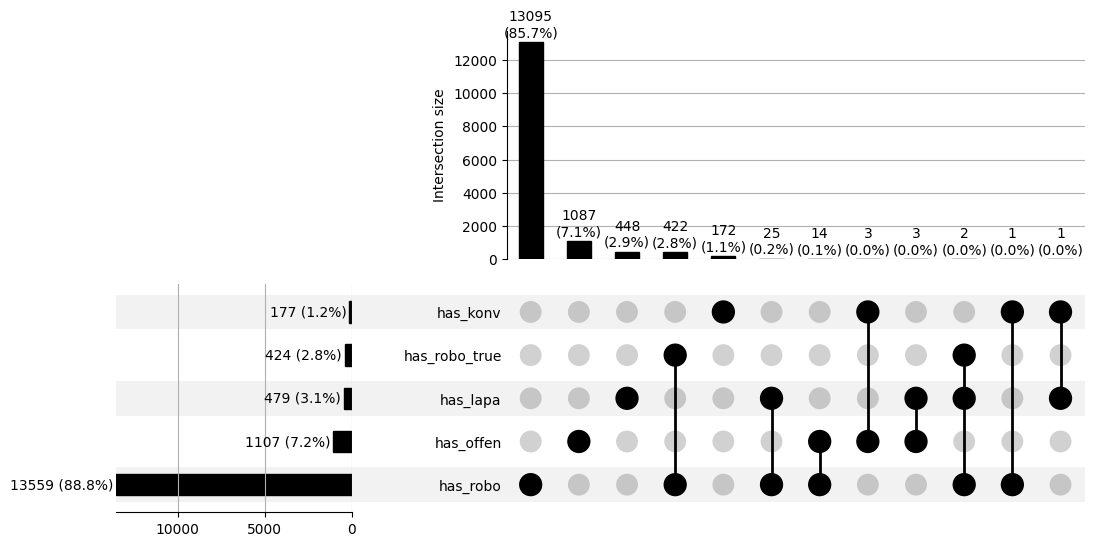

In [21]:
FILTERS_OPS_ILEO = ("(left(Code,8) in ('5-455.21', '5-455.25', '5-455.27') OR left(Code,5) in ('5-987'))", "OPS ileo")

_filters_ileo = [
    FILTERS_DY,
    FILTERS_C18C20,
    FILTERS_OP_COUNT,
    FILTERS_OPS_ILEO,
]
_filter_ileo=hlp.get_duckdb_filter_n(
    con=con,
    query="""--sql
        from Tumor tum
        left join OPS ops on tum.z_tum_id = ops.z_tum_id
        """,
    filters=_filters_ileo,
    distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=2,
)

db_ops_upset_4552 = con.sql(f"""--sql
    with t1 as (
        select
            tu.z_tum_id,
            z_kkr_label,
            case when left(ops.Code,8) in ('5-455.21') then true else false end as offen,
            case when left(ops.Code,8) in ('5-455.25') then true else false end as lapa,
            case when left(ops.Code,8) in ('5-455.27') then true else false end as konv,
            case when left(ops.Code,8) in ('5-987.01') then true else false end as robo_true,
            case when left(ops.Code,5) in ('5-987') then true else false end as robo,
        from Tumor tu
        left join OP op on tu.z_tum_id = op.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        where {_filter_ileo}
    ), t2 as (
        select
            z_tum_id,
            max(offen) as has_offen,
            max(lapa) as has_lapa,
            max(konv) as has_konv,
            max(robo_true) as has_robo_true,
            max(robo) as has_robo,
        from t1
        group by z_tum_id
    )
    select * from t2
""")

# ? debug
# db_ops_upset_4552.filter("has_robo_true").show()

pls.plot_upset(db_ops_upset_4552.to_df().iloc[:,-5:],include_false_subsets=False)

#### <a id='toc1_5_4_2_'></a>[rechte Hemikolektomie](#toc0_)
- Filter: alle Tumore, die einen OPS Code `5-455.4` aufweisen
- gezählt sind Tumore
- die Gruppen können überlappen

> 💡 kaum Robotik `5-987.1` geschlüsselt für diese Tumore (n=4)

<!-- START_TOKEN -->

counts: distinct z_tum_id
---
n = 4_015_983
└ [DJ 2020-2024]:  n = 3_758_513
└ [ICD10 C18-C20]: n = 284_931 (100.0%) ██████████████████████████████
└ [> 0 OPS]:       n = 185_576  (65.1%) ░░░░░░░░░░░███████████████████
└ [OPS hemi]:       n = 64_632  (22.7%) ░░░░░░░░░░░░░░░░░░░░░░░░██████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18','C19','C20')
and z_tum_op_count > 0
and 
    (
        left(Code,8) in ('5-455.41', '5-455.45', '5-455.47')
        OR left(Code,5) in ('5-987')
    )
```

</details>

n = 64_632 | n(true) = 64_632


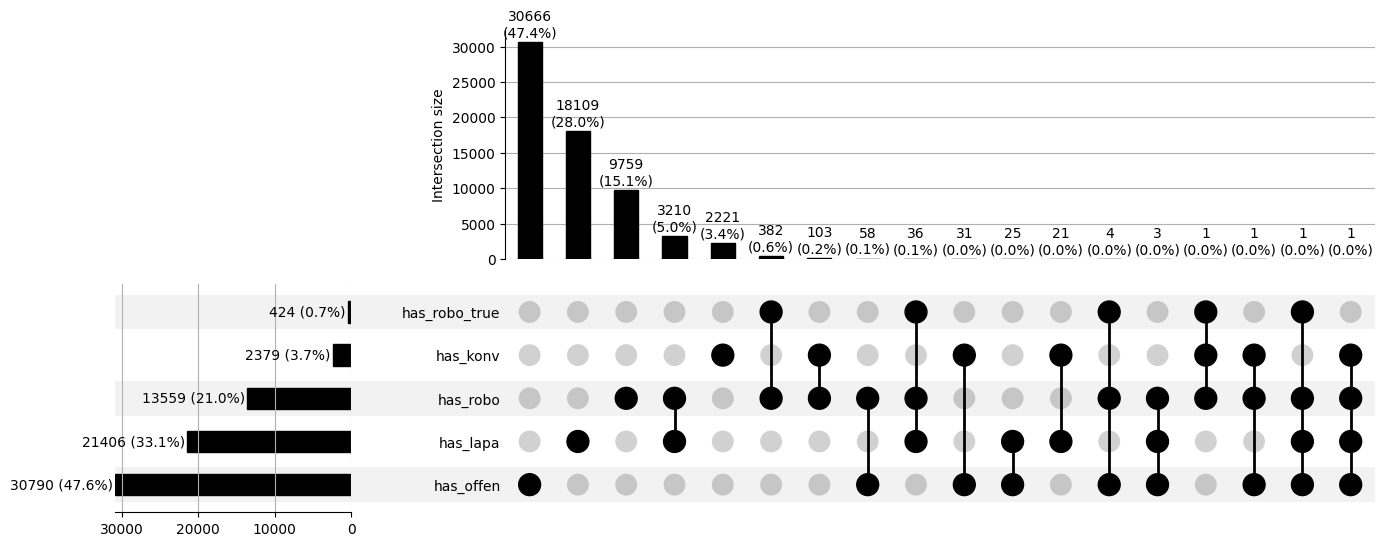

In [22]:
_filters_hemi = [
    FILTERS_DY,
    FILTERS_C18C20,
    FILTERS_OP_COUNT,
    FILTERS_OPS_HEMI,
]
_filter_hemi=hlp.get_duckdb_filter_n(
    con=con,
    query="""--sql
        from Tumor tum
        left join OPS ops on tum.z_tum_id = ops.z_tum_id
        """,
    filters=_filters_hemi,
    distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=2,
)

db_ops_upset_4554 = con.sql(f"""--sql
    with t1 as (
        select
            tu.z_tum_id,
            z_kkr_label,
            case when left(ops.Code,8) in ('5-455.41') then true else false end as offen,
            case when left(ops.Code,8) in ('5-455.45') then true else false end as lapa,
            case when left(ops.Code,8) in ('5-455.47') then true else false end as konv,
            case when left(ops.Code,8) in ('5-987.01') then true else false end as robo_true,
            case when left(ops.Code,5) in ('5-987') then true else false end as robo,
        from Tumor tu
        left join OP op on tu.z_tum_id = op.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        where {_filter_hemi}
    ), t2 as (
        select
            z_tum_id,
            max(offen) as has_offen,
            max(lapa) as has_lapa,
            max(konv) as has_konv,
            max(robo_true) as has_robo_true,
            max(robo) as has_robo,
        from t1
        group by z_tum_id
    )
    select * from t2
""")

# ? debug
# db_ops_upset_4554.filter("has_robo_true").show()

pls.plot_upset(db_ops_upset_4554.to_df().iloc[:,-5:],include_false_subsets=False)

#### <a id='toc1_5_4_3_'></a>[Sigmaresektion](#toc0_)
- Filter: alle Tumore, die einen OPS Code `5-455.7` aufweisen
- gezählt sind Tumore
- die Gruppen können überlappen

> 💡 kaum Robotik `5-987.1` geschlüsselt für diese Tumore (n=4)

<!-- START_TOKEN -->

counts: distinct z_tum_id
---
n = 4_015_983
└ [DJ 2020-2024]:  n = 3_758_513
└ [ICD10 C18-C20]: n = 284_931 (100.0%) ██████████████████████████████
└ [> 0 OPS]:       n = 185_576  (65.1%) ░░░░░░░░░░░███████████████████
└ [OPS sigma]:      n = 28_345   (9.9%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18','C19','C20')
and z_tum_op_count > 0
and 
    (
        left(Code,8) in ('5-455.71', '5-455.75', '5-455.77')
        OR left(Code,5) in ('5-987')
    )
```

</details>

n = 28_345 | n(true) = 28_345


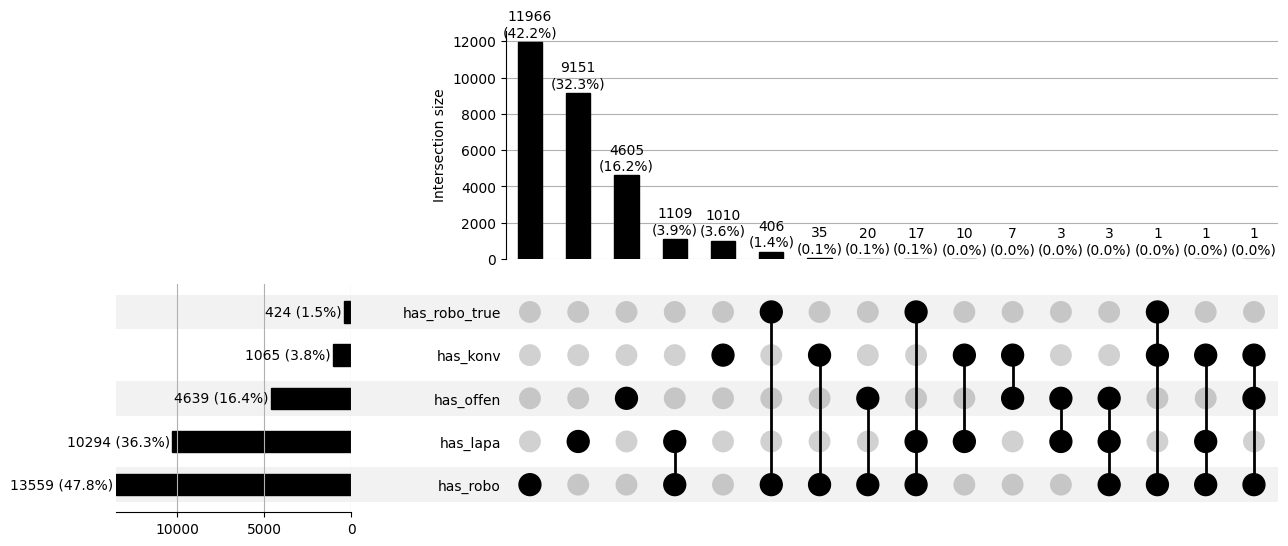

In [23]:
_filters_sig = [
    FILTERS_DY,
    FILTERS_C18C20,
    FILTERS_OP_COUNT,
    FILTER_OPS_SIG,
]

_filter_sig=hlp.get_duckdb_filter_n(
    con=con,
    query="""--sql
        from Tumor tum
        left join OPS ops on tum.z_tum_id = ops.z_tum_id
        """,
    filters=_filters_sig,
    distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=2,
)

db_ops_upset_4557 = con.sql(f"""--sql
    with t1 as (
        select
            tu.z_tum_id,
            z_kkr_label,
            case when left(ops.Code,8) in ('5-455.71') then true else false end as offen,
            case when left(ops.Code,8) in ('5-455.75') then true else false end as lapa,
            case when left(ops.Code,8) in ('5-455.77') then true else false end as konv,
            case when left(ops.Code,8) in ('5-987.01') then true else false end as robo_true,
            case when left(ops.Code,5) in ('5-987') then true else false end as robo,
        from Tumor tu
        left join OP op on tu.z_tum_id = op.z_tum_id
        left join OPS ops on op.OPId = ops.OP_TypId
        where {_filter_sig}
    ), t2 as (
        select
            z_tum_id,
            max(offen) as has_offen,
            max(lapa) as has_lapa,
            max(konv) as has_konv,
            max(robo_true) as has_robo_true,
            max(robo) as has_robo,
        from t1
        group by z_tum_id
    )
    select * from t2
""")

# ? debug
# db_ops_upset_4557.filter("has_robo_true").show()

pls.plot_upset(db_ops_upset_4557.to_df().iloc[:,-5:],include_false_subsets=False)

## <a id='toc1_6_'></a>[Lokalisation (Fernmetastasen)](#toc0_)


### <a id='toc1_6_1_'></a>[für M1](#toc0_)
- Filter: `C18`-`C20`, nur `M1`
- gezählt sind Tumore. Allerdings: Bei mehrfachen FM Angaben werden Tumore **mehrfach** gezählt

> 💡 45% von M1 haben Leber FM

In [24]:
fm1 = db_colon.filter("z_m_pc_1 in ('1')").count("distinct z_tum_id").fetchall()[0][0]
fm0 = db_colon.filter("z_m_pc_1 in ('0')").count("distinct z_tum_id").fetchall()[0][0]
print(f"{fm1:_} Tumore im Filter haben M1, {fm0:_} haben M0")

599_875 Tumore im Filter haben M1, 590_898 haben M0


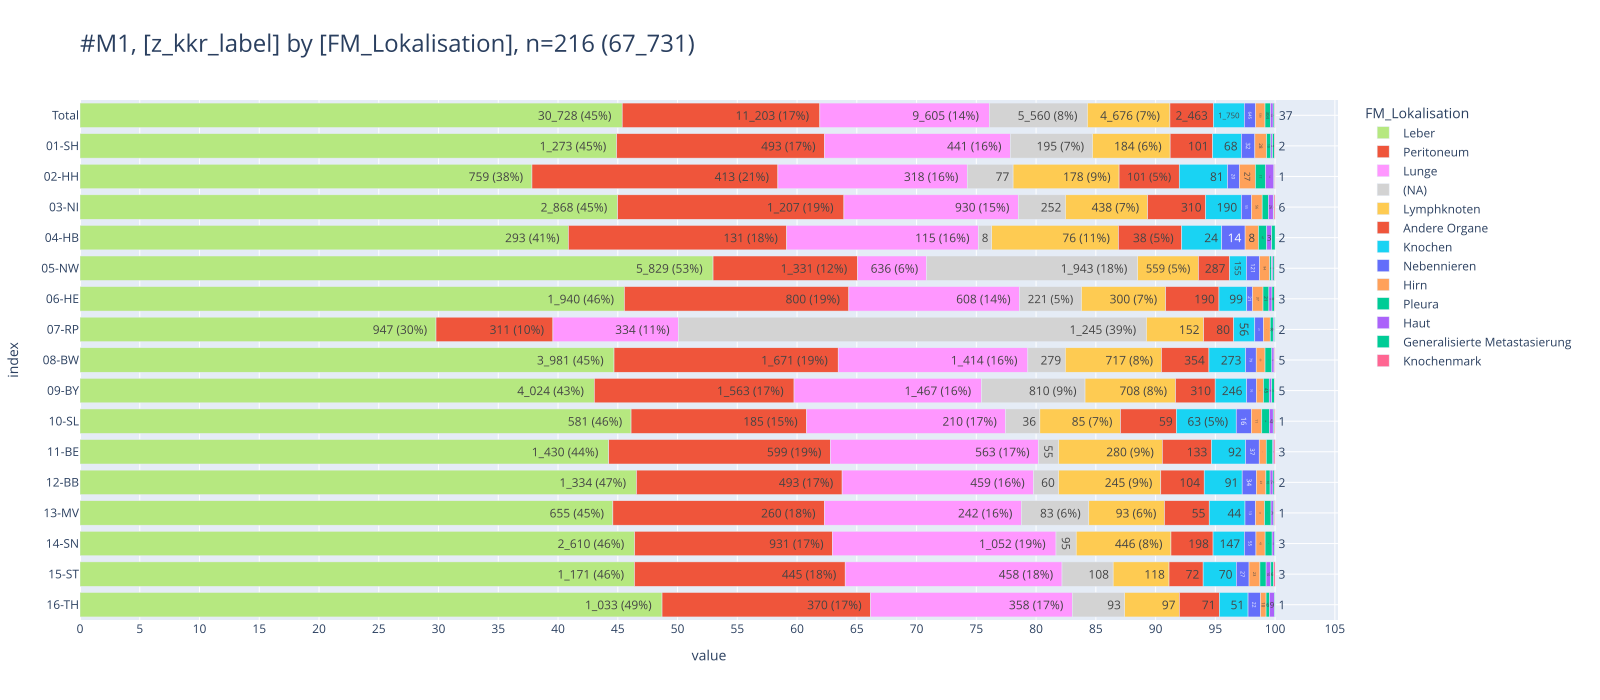

In [25]:
# _filters_lok = [
#     FILTERS_DY,
#     FILTERS_COLORECTAL,
#     ("z_m_pc_1 in ('1')", "nur M1"),
# ]

# _filter_lok=hlp.get_duckdb_filter_n(
#     con=con,
#     query="""--sql
#         from Tumor
#         """,
#     filters=_filters_lok,
#     # distinct_metric="z_tum_id",
#     first_n_filter_apply_to_rows=2,
# )


df = (db_colon
    .filter("z_m_pc_1 in ('1')")
    .aggregate("""--sql
            z_kkr_label, FM_Lokalisation,
            count(distinct z_tum_id) as cnt_tum
        """)
    .to_df()
)

_=pls.plot_stacked_bars(
    df,
    relative=True,
    show_total=True,
    orientation="h",
    sort_values=False,
    height=700,
    width=1600,
    caption="M1",
    sort_values_color=True,
    show_pct_bar=True,
)
# tbl.pivot_df(df, data_bar_axis="xy", pct_axis="xy", swap=True)

## <a id='toc1_7_'></a>[Rezidive](#toc0_)

### <a id='toc1_7_1_'></a>[Verteilung OP in 2020](#toc0_)
- Filter: `C18`-`C20`, 2020
- gezählt sind Tumore
- Einteilung der Verteilung in eine Kategorie Tabelle
  - `1_op_r0` - OP und R0 dokumentiert
  - `2_op_no_r0` - OP, kein R0
  - `3_no_op_but_pt` - keine OP, aber pT (Diagnose oder Verlauf)
  - `4_no_op_pt_but_st_sy` - keine OP, keine pT, aber ST oder SYST
  - `5_no_op_st_sy_pt` - keine Therapie oder pT


<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 4_015_983
└ [DJ 2020-2024]:  n = 3_758_513
└ [ICD10 C18-C20]: n = 284_931 (100.0%) ██████████████████████████████
└ [DJ 2020]:        n = 57_998  (20.4%) ░░░░░░░░░░░░░░░░░░░░░░░░██████
└ [nur C18]:        n = 39_315  (13.8%) ░░░░░░░░░░░░░░░░░░░░░░░░░░████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18','C19','C20')
and z_dy = 2020
and z_icd10_3d in ('C18')
```

</details>

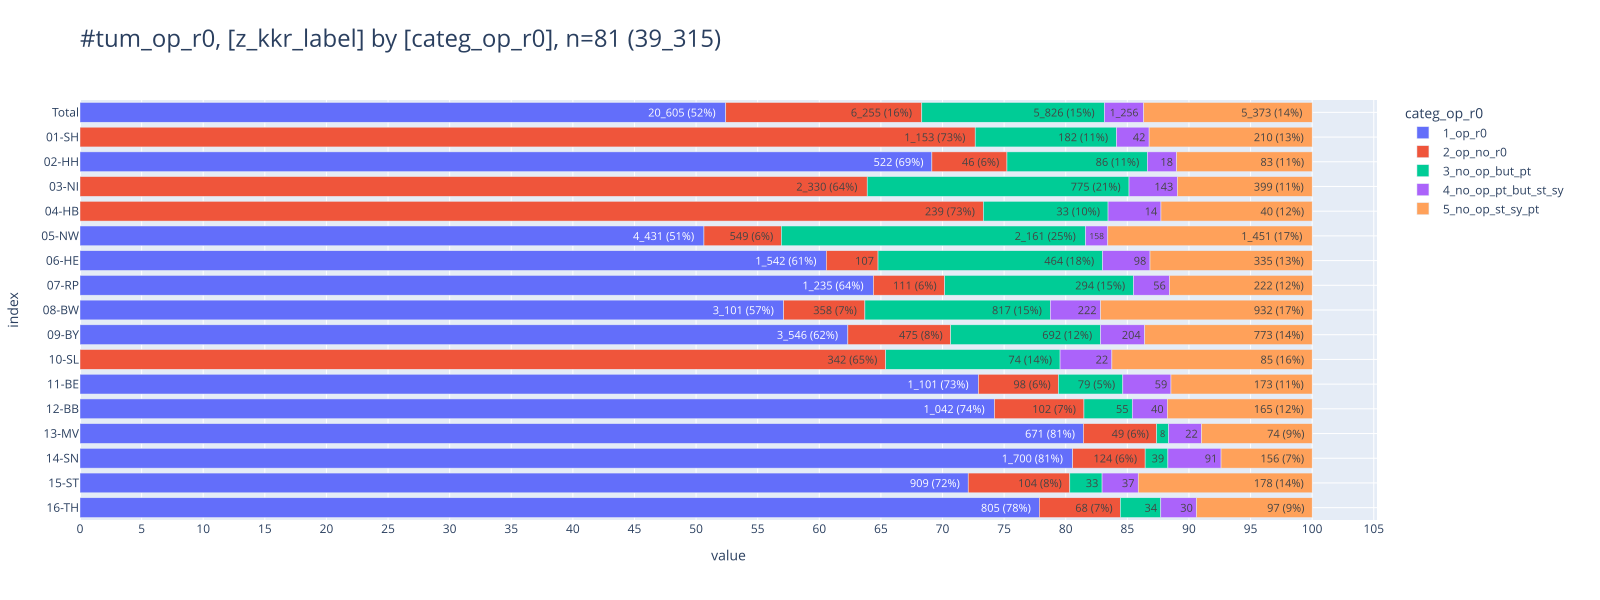

In [26]:

_filters_rez = [
    FILTERS_DY,
    FILTERS_C18C20,
    FILTERS_2020,
    FILTERS_C18,
]

_filter_rez=hlp.get_duckdb_filter_n(
    con=con,
    query="""--sql
        from Tumor
        """,
    filters=_filters_rez,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=2,
)

db_r0 = con.sql(f"""--sql
    with t1 as (
        select  tum.z_tum_id,
                z_kkr_label,
                upper(left(op.Lokale_Beurteilung_Residualstatus,2)) as r_status,
                z_tum_op_count,
                z_tum_sy_count,
                z_tum_st_count,
                z_t_p_1 as pt_tum,
                case when
                    (ifnull(fo.T,'0') <> '0' and fo.c_p_u_Praefix_T = 'p')
                    or ifnull(z_t_p_1,'0') <> '0'
                    then true else false end as has_pt,
                case when z_tum_sy_count > 0 or z_tum_st_count > 0 then true else false end as has_st_sy,
                fo.T as t_fo,
                fo.c_p_u_Praefix_T as cpu_fo
        from Tumor tum
        join Patient pat on tum.z_pat_id = pat.oBDS_RKIPatientId
        left join OP op on op.z_tum_id = tum.z_tum_id
        left join Folgeereignis_TNM fo on fo.z_tum_id = tum.z_tum_id
        where {_filter_rez}
    ),
    t2 as (
        select  z_tum_id,
                any_value(z_kkr_label) as z_kkr_label,
                any_value(z_tum_op_count) as z_tum_op_count,
                any_value(z_tum_sy_count) as z_tum_sy_count,
                any_value(z_tum_st_count) as z_tum_st_count,
                max(ifnull(r_status,'')='R0') as has_r_status,
                max(has_st_sy) as has_st_sy,
                max(has_pt) as has_pt,
        from t1
        group by z_tum_id
    ),
    t3 as (
        select  *,
                case
                    when z_tum_op_count = 0 and not has_st_sy and not has_pt then '1_no_op_st_sy_pt'
                    when z_tum_op_count = 0 and not has_st_sy and has_pt then '2_no_op_st_sy_but_pt'
                    when z_tum_op_count = 0 and has_st_sy and not has_pt then '3_no_op_pt_but_st_sy'
                    when z_tum_op_count = 0 and has_st_sy and has_pt then '4_no_op_but_st_sy_pt'
                    when not has_r_status then '5_op_no_r0'
                    when has_r_status then '6_op_r0'
                    else '9_unknown'
                end as categ_op_r0__,
                case
                    when z_tum_op_count = 0 then '1_no_op'
                    when not has_r_status then '2_op_no_r0'
                    when has_r_status then '3_op_r0'
                    else '9_unknown'
                end as categ_op_r0_,
                case
                    when z_tum_op_count > 0 and has_r_status then '1_op_r0'
                    when z_tum_op_count > 0 and not has_r_status then '2_op_no_r0'
                    when has_pt then '3_no_op_but_pt'
                    when has_st_sy then '4_no_op_pt_but_st_sy'
                    when not has_st_sy then '5_no_op_st_sy_pt'
                    else '9_unknown'
                end as categ_op_r0,
                
        from t2
    )
    select * from t3
""")


pls.plot_stacked_bars(
    db_r0.project("z_kkr_label, categ_op_r0").to_df(),
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="tum_op_r0",
    height=600,
    width=1600,
    # kkr_col="z_kkr_label"
    )
# tbl.pivot_df(db_r0.project("z_kkr_label, categ_op_r0").to_df(), swap=False, )


- `r_status`
  - `1_R0`: wenn >= 1 OP zum Tumor dokumentiert is mit `R0`
  - `2_R1_R2`: wenn kein `R0` dokumentiert, aber >= 1 OP mit `R1` oder `R2`
  - `3_NA_U_RX`: wenn beides nicht zutrifft (Feld ist leer, `U` oder `RX`)

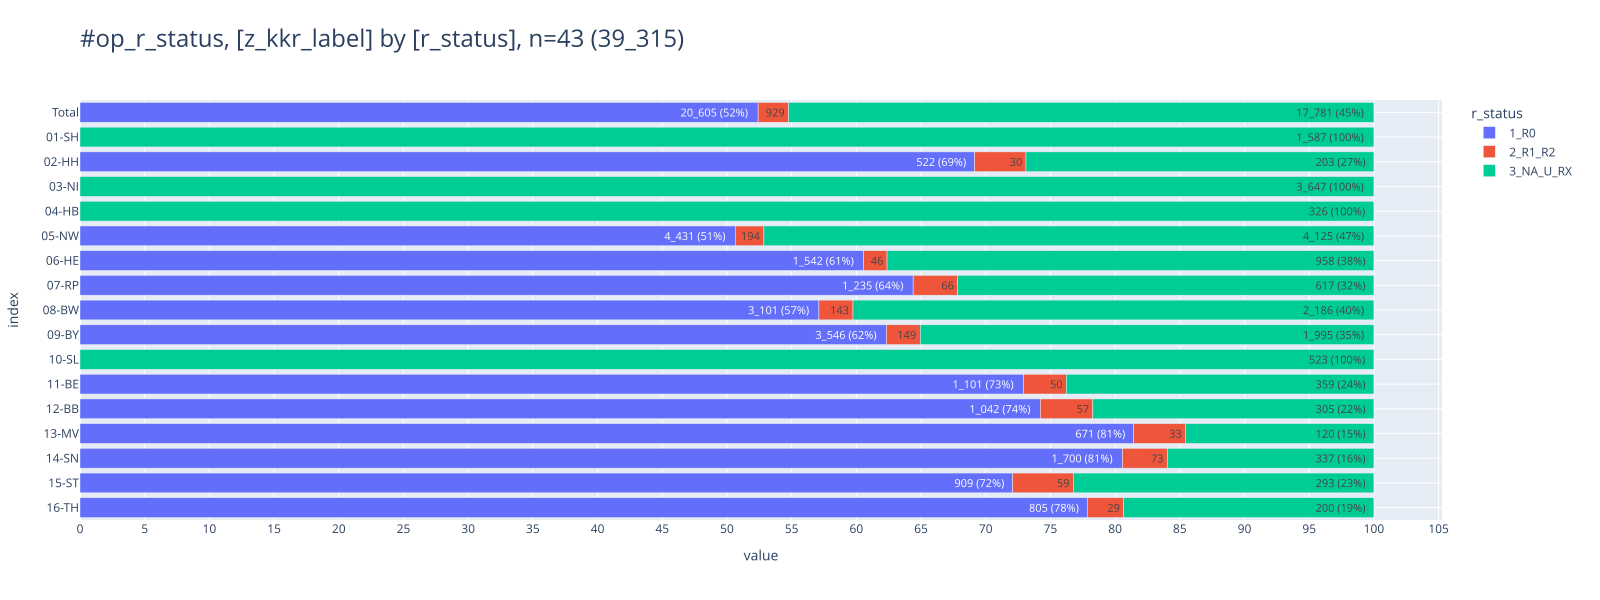

r_status,1_R0,2_R1_R2,3_NA_U_RX,Total
z_kkr_label,,,,
01-SH,0,0,1_587,1_587
02-HH,522,30,203,755
03-NI,0,0,3_647,3_647
04-HB,0,0,326,326
05-NW,4_431,194,4_125,8_750
06-HE,1_542,46,958,2_546
07-RP,1_235,66,617,1_918
08-BW,3_101,143,2_186,5_430
09-BY,3_546,149,1_995,5_690


In [27]:
db_r0_2 = con.sql(f"""--sql
    with t1 as (
        select
            tum.z_tum_id,
            z_kkr_label,
            case
                when upper(left(op.Lokale_Beurteilung_Residualstatus,2)) in ('R0') then '1_R0'
                when upper(left(op.Lokale_Beurteilung_Residualstatus,2)) in ('R1', 'R2') then '2_R1_R2'
                when
                    upper(left(op.Lokale_Beurteilung_Residualstatus,2)) in ('RX')
                    or upper(left(ifnull(op.Lokale_Beurteilung_Residualstatus,'U'),1)) in ('U')
                    then '3_NA_U_RX'
                else 'U'
            end as r_status,
        from Tumor tum
        left join OP op on op.z_tum_id = tum.z_tum_id
        where {_filter_rez}
    ),
    t2 as (
        select
                z_tum_id,
                any_value(z_kkr_label) as z_kkr_label,
                min(r_status) as r_status
        from t1
        group by z_tum_id
    )
    select * from t2
""")

pls.plot_stacked_bars(
    db_r0_2.project("z_kkr_label, r_status").to_df(),
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="op_r_status",
    height=600,
    width=1600,
    # kkr_col="z_kkr_label"
)

tbl.pivot_df(
    db_r0_2.project("z_kkr_label, r_status").to_df(),
    # swap=True,
    data_bar_axis="x",
    pct_axis="",
    total_exclude=True,
    font_size_th=9,
    font_size_td=7,
)

#### <a id='toc1_7_1_1_'></a>[davon: Verteilung nur R0](#toc0_)

**enge Definition eines Rezidivs** 
- Filter: lokaler Beurteilung Residualstatus = R0 (UND M <> 1)
- Rezidiv wenn  
  - Gesamtbeurteilung: Y  oder  
  - Lokaler Tumorstatus: R  oder  
  - Tumorstatus Lymphknoten:R oder  
  - Verlauf Fernmetastasen:R   

**erweiterte Definition (Verworfen)**
- Rezidiv wenn
  - (TNM)r_Symbol:r UND 
  - (Folgeereignis T>0 oder Folgeereignis N>0 oder Folgeereignis M>0)

**Diagramm**
- gezählt sind Tumore mit R0
- Kategorien
  - `1_fo_relapse` - Tumore mit Rezidiv nach enger Definition
  - `2_fo_relapse_tnm` - Tumore mit Rezidiv nach erweiterter Definition
  - `3_fo_no_relapse` - Tumore mit Folgeereignis ohne o.a. Rezidiv
  - `4_no_fo` - Tumore ohne Folgeereignis
- ℹ️ kkr mit "leerem Balken" nicht nicht in der Grundmenge enthalten, da sie keine R0 ausweisen

<!-- START_TOKEN -->

counts: distinct z_tum_id
---
n = 4_015_983
└ [DJ 2020]:           n = 749_493
└ [nur C18]:           n = 39_315 (100.0%) ██████████████████████████████
└ [Residualstatus R0]: n = 20_605  (52.4%) ░░░░░░░░░░░░░░░███████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy = 2020
and z_icd10_3d in ('C18')
and upper(left(Lokale_Beurteilung_Residualstatus,2)) = 'R0'
```

</details>

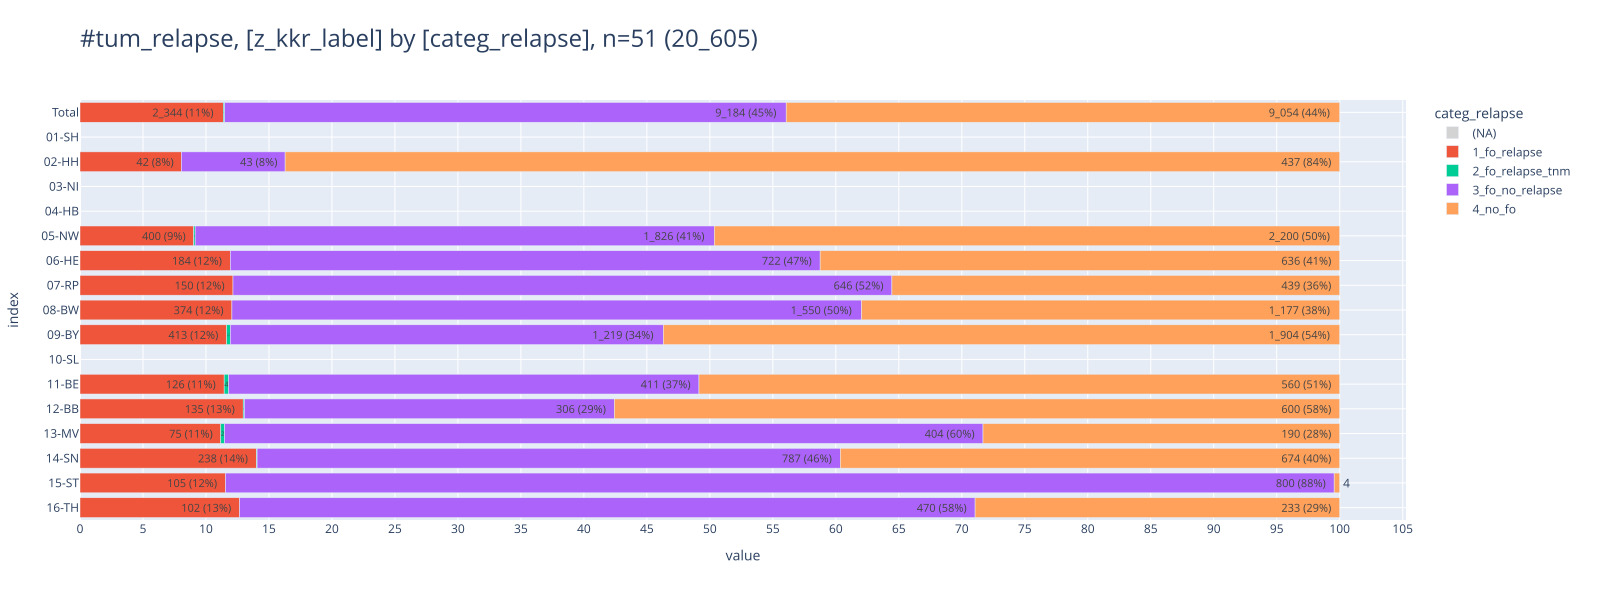

categ_relapse,1_fo_relapse,2_fo_relapse_tnm,3_fo_no_relapse,4_no_fo,Total
z_kkr_label,,,,,
02-HH,42,0,43,437,522
05-NW,400,5,1_826,2_200,4_431
06-HE,184,0,722,636,1_542
07-RP,150,0,646,439,1_235
08-BW,374,0,1_550,1_177,3_101
09-BY,413,10,1_219,1_904,3_546
11-BE,126,4,411,560,1_101
12-BB,135,1,306,600,1_042
13-MV,75,2,404,190,671


In [28]:
_filters_r0 = [
    FILTERS_2020,
    FILTERS_C18,
    FILTERS_R0,
    # FILTERS_M0,
]

_filter_r0=hlp.get_duckdb_filter_n(
    con=con,
    query="""--sql
        from Tumor tum
        left join OP op on op.z_tum_id = tum.z_tum_id
        """,
    filters=_filters_r0,
    distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=2,
)

db_rez = con.sql(f"""--sql
    with t1 as (
        select  tum.z_tum_id
                ,z_pat_id
                ,fol.FolgeereignisId
                ,z_kkr_label
                ,z_m_pc_1
                ,fol.Gesamtbeurteilung_Tumorstatus
                ,fol.Verlauf_Lokaler_Tumorstatus 
                ,fol.Verlauf_Tumorstatus_Lymphknoten
                ,fol.Verlauf_Tumorstatus_Fernmetastasen
                ,r_Symbol
                ,T, N, M
        from Tumor tum
        join Patient pat on tum.z_pat_id = pat.oBDS_RKIPatientId
        left join op on op.z_tum_id = tum.z_tum_id
        left join Folgeereignis fol on fol.z_tum_id = tum.z_tum_id
        left join Folgeereignis_TNM tnm on tnm.z_tum_id = tum.z_tum_id
        where {_filter_r0}
        --and ifnull(z_m_pc_1,'0') <> '1'
    ),
    t2 as (
        select  *
                ,(Gesamtbeurteilung_Tumorstatus ==  'Y') as has_gesamt
                ,(Verlauf_Lokaler_Tumorstatus == 'R') as has_lokal
                ,(Verlauf_Tumorstatus_Lymphknoten == 'R') as has_lymph
                ,(Verlauf_Tumorstatus_Fernmetastasen == 'R') as has_fm
                -- extended
                ,(r_Symbol is not null) as has_r_symbol
                ,(left(T,1) in ('1','2','3','4')) as has_t2plus
                ,(left(N,1) in ('1','2','3','4')) as has_n2plus
                ,(left(M,1) in ('1','2','3','4')) as has_m2plus
        from t1
    ),
    t3 as (
        select  z_tum_id
                ,first(z_pat_id) as z_pat_id
                ,first(FolgeereignisId) as FolgeereignisId
                ,first(z_m_pc_1) as z_m_pc_1
                ,first(z_kkr_label) as z_kkr_label
                --,max(has_r0)::text as has_r0
                ,max(has_gesamt)::text as has_gesamt
                ,max(has_lokal)::text as has_lokal
                ,max(has_lymph)::text as has_lymph
                ,max(has_fm)::text as has_fm
                ,max(has_r_symbol)::text as has_r_symbol
                ,max(has_t2plus)::text as has_t2plus
                ,max(has_n2plus)::text as has_n2plus
                ,max(has_m2plus)::text as has_m2plus
        from t2
        group by z_tum_id
    ),
    t4 as (
        select  t3.*
                ,pat.Verstorben
                ,case when (has_gesamt or has_lokal or has_lymph or has_fm) then true else false end as has_rel1
                ,case when (has_gesamt or has_lokal or has_lymph or has_fm) or ((has_t2plus or has_n2plus or has_m2plus)) then true else false end as has_rel2
                ,case 
                    when FolgeereignisId is not null and (has_gesamt or has_lokal or has_lymph or has_fm) then '1_fo_relapse'
                    when FolgeereignisId is not null and has_r_symbol and (has_t2plus or has_n2plus or has_m2plus) then '2_fo_relapse_tnm'
                    --when FolgeereignisId is not null and Verstorben = 'J' then '3_fo_deceased'
                    when FolgeereignisId is not null then '3_fo_no_relapse'
                    when FolgeereignisId is null then '4_no_fo'
                    else '9_unknown'
                end as categ_relapse
        from t3
        join Patient pat on pat.oBDS_RkiPatientId = t3.z_pat_id
    )
    select * from t4
""")
# tbl.descr_db(db_rez, "relapse")
n_tum = con.sql("select count(*) from db_rez").fetchone()[0]
# print(f"FILTER: {FILTER} | darin {n_tum:_} Tumore")

pls.plot_stacked_bars(
    db_rez.project("z_kkr_label, categ_relapse").to_df(),
    relative=True,
    show_total=True,
    orientation="h",
    show_pct_bar=True,
    caption="tum_relapse",
    height=600,
    width=1600,
    kkr_col="z_kkr_label"
)

tbl.pivot_df(
    db_rez.project("z_kkr_label, categ_relapse").to_df(),
    swap=False,
    pct_axis="",
)

<br>

## <a id='toc1_8_'></a>[Behandlung innerhalb von 6 Wochen](#toc0_)
- Filter: `C18`-`C20`
- `first_treatment_6w`
  - `<=6w`: erste Behandlung innerhalb von 6 Wochen
  - `>6w`: erste Behandlung nach 6 Wochen
  - `-`: keine Behandlung dokumentiert

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 4_015_983                    (100.0%) ██████████████████████████████
└ [DJ 2020-2024]:  n = 3_758_513  (93.6%) ░░████████████████████████████
└ [ICD10 C18-C20]:   n = 284_931   (7.1%) ░░░░░░░░░░░░░░░░░░░░░░░░░░░░██


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18','C19','C20')
```

</details>

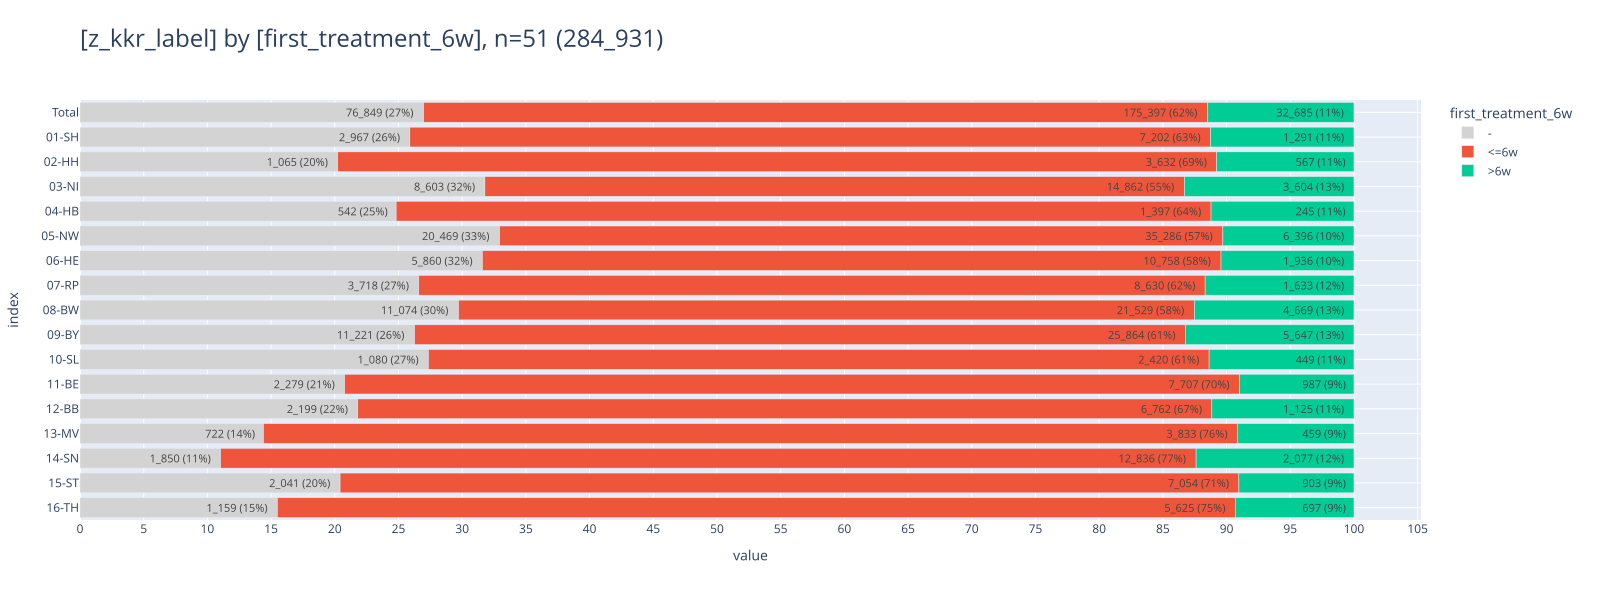

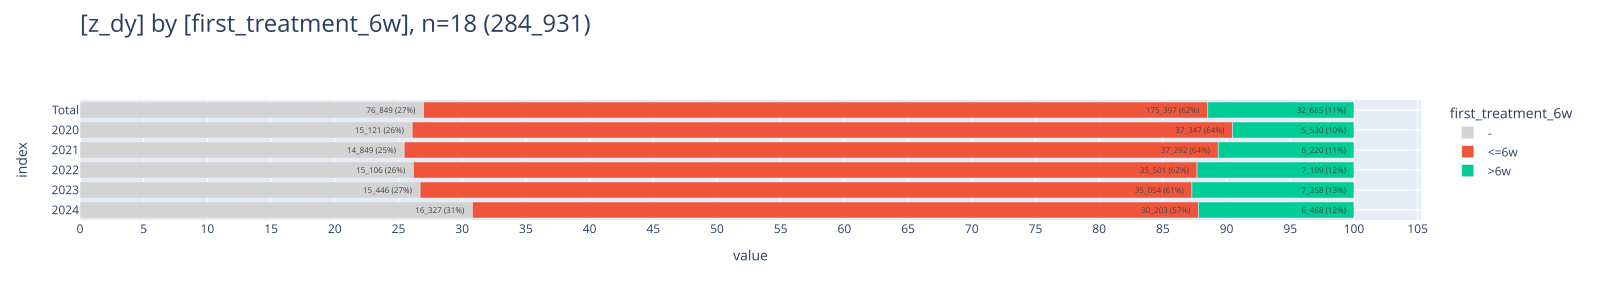

In [29]:
_filters_6w = [
    FILTERS_DY,
    FILTERS_C18C20,
]

_filter_6w=hlp.get_duckdb_filter_n(
    con=con,
    query="""--sql
        from Tumor tum
        """,
    filters=_filters_6w,
    # distinct_metric="z_tum_id",
    # first_n_filter_apply_to_rows=2,
)

_df = con.sql(f"""--sql
    select
        tum.z_tum_id,
        tum.z_dy::text as z_dy,
        z_kkr_label,
        z_first_treatment_after_days,
        case
            when z_first_treatment_after_days is null then '-'
            when z_first_treatment_after_days < 43 then '<=6w'
            when z_first_treatment_after_days >= 43 then '>6w'
        else 'U' end
        as first_treatment_6w,
    from Tumor tum
    --left join OP op on op.z_tum_id = tum.z_tum_id
    where {_filter_6w}
""").to_df()

# display(_df)

_=pls.plot_stacked_bars(
    _df[["z_kkr_label", "first_treatment_6w"]],
    relative=True,
    show_total=True,
    orientation="h",
    sort_values=False,
    height=600,
    show_pct_bar=True,
    first_col_grey=True,
)
_=pls.plot_stacked_bars(
    _df[["z_dy", "first_treatment_6w"]],
    relative=True,
    show_total=True,
    orientation="h",
    sort_values=False,
    height=300,
    show_pct_bar=True,
    first_col_grey=True,
)

# tbl.pivot_df(df, data_bar_axis="xy", pct_axis="xy", swap=True)

## <a id='toc1_9_'></a>[Erste Behandlung](#toc0_)

### <a id='toc1_9_1_'></a>[Was wurde zuerst behandelt](#toc0_)
- Filter: `M1` und Tumor hat Lebermetastasen und `C18` oder `C20`
- gezählt sind Tumore

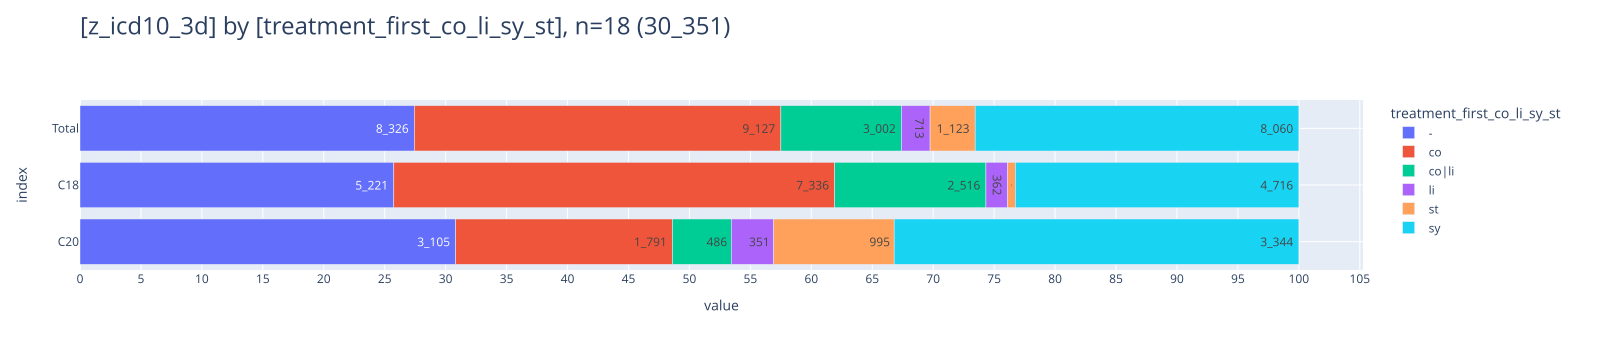

In [30]:
_df = (db_colon
    .filter("z_icd10_3d in ('C18','C20') and z_m_pc_1 = '1' and FM_Lokalisation = 'Leber'")
    .aggregate("""--sql
            z_tum_id,
            first(z_icd10_3d) as z_icd10_3d,
            first(treatment_first_co_li_sy_st) as treatment_first_co_li_sy_st,
    """)
    )
# print(f"Anzahl Tumore: {_df.count("distinct z_tum_id").fetchall()[0][0]:_}")

_=pls.plot_stacked_bars(_df.to_df().iloc[:,-2:], relative=True, show_total=True, orientation="h", height=350)

### <a id='toc1_9_2_'></a>[Zeitlicher Abstand der Behandlungen](#toc0_)
- Filter: `C18`, Tumore mit Behandlung
- gezählt sind Tumore
- abgebildet sind Median Werte für den Abstand Diagnose bis erste Behandlung in Tagen (logarithmische Skala)

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 4_015_983
└ [DJ 2020-2024]:          n = 3_758_513
└ [nur C18]:               n = 193_488 (100.0%) ██████████████████████████████
└ [Tumore mit Behandlung]: n = 139_477  (72.1%) ░░░░░░░░░█████████████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18')
and 
    ifnull(z_first_treatment,'') <> ''
    and z_first_treatment_after_days >= 0
    
```

</details>

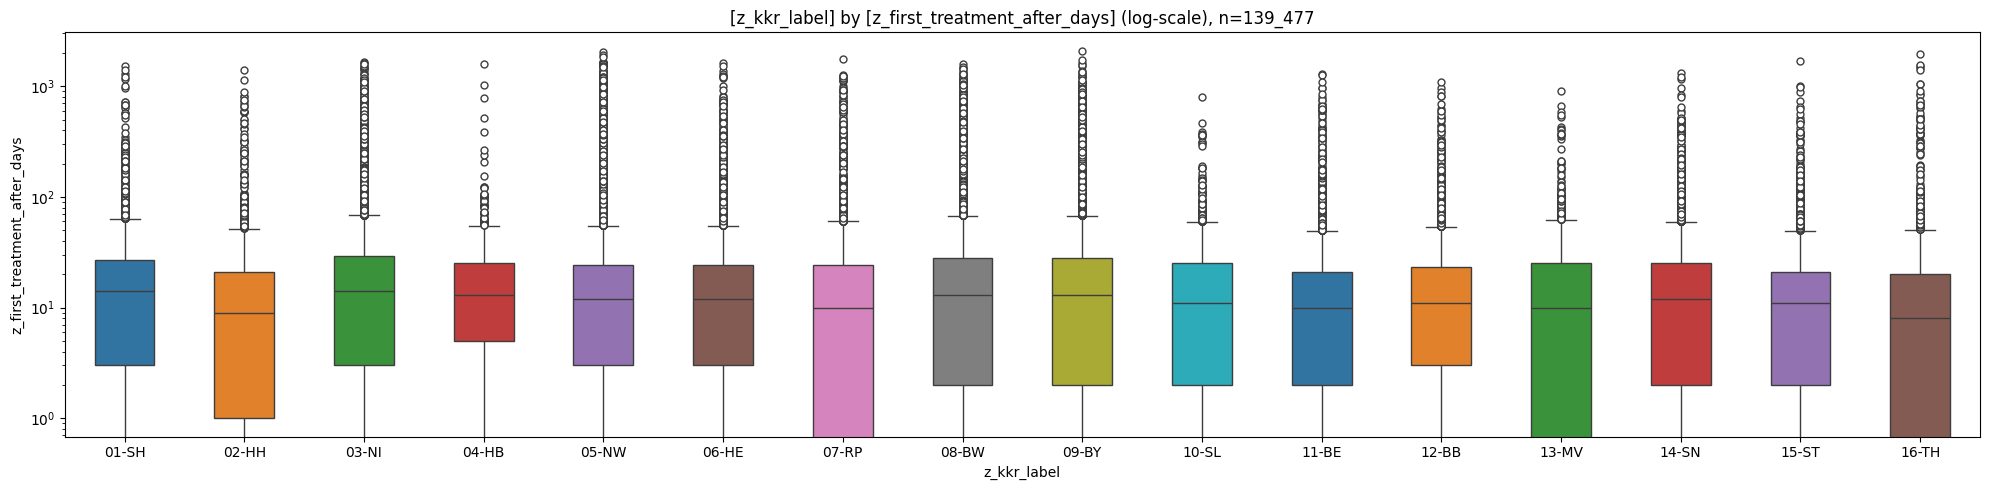


column (n = 139_477)         |    notnull     | min | lower | q25  | median | mean  |  q75  | upper |  max  |  std  |  cv 
-----------------------------+----------------+-----+-------+------+--------+-------+-------+-------+-------+-------+-----
z_first_treatment_after_days | 139_477 (100%) |   0 |     0 | 2.00 |  12.00 | 24.94 | 25.00 |    59 | 2_092 | 73.57 | 2.95


item (n = 139_477) | count  | min  | lower | q25  | median | mean  |  q75  | upper |   max    |  std  |  cv 
-------------------+--------+------+-------+------+--------+-------+-------+-------+----------+-------+-----
01-SH              |  5_899 | 0.00 |  0.00 | 3.00 |  14.00 | 22.26 | 27.00 | 63.00 | 1_520.00 | 56.66 | 2.54
02-HH              |  2_962 | 0.00 |  0.00 | 1.00 |   9.00 | 21.21 | 21.00 | 51.00 | 1_413.00 | 65.26 | 3.08
03-NI              | 12_255 | 0.00 |  0.00 | 3.00 |  14.00 | 28.50 | 29.00 | 68.00 | 1_645.00 | 83.94 | 2.95
04-HB              |  1_172 | 0.00 |  0.00 | 5.00 |  13.00 | 21.88 | 25.00 | 55.00 

In [31]:
_filters_treat = [
    FILTERS_DY,
    FILTERS_C18,
    FILTERS_HAS_TREAT
]

_filter_treat=hlp.get_duckdb_filter_n(
    con=con,
    query="""--sql
        from Tumor tum
        """,
    filters=_filters_treat,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=2,
)

db_delay = con.sql(f"""--sql
    select
            z_kkr_label,
            z_first_treatment_after_days, 
            z_first_treatment
    from Tumor
    where {_filter_treat}
    """)
# tbl.descr_db(db_delay)

_ = pls.plot_boxes_large(
    # _df[["z_kkr_label", "z_first_treatment_after_days"]],
    db_delay.to_df().iloc[:,:2],
    height=500,
    width=2000,
    use_log=True,
)
#139477

## <a id='toc1_10_'></a>[Behandlungsverlauf](#toc0_)
- Filter: `C18`, nur Tumore mit Therapie
- gezählt sind Tumore
- beschränkt auf die ersten 5 Therapien
- Therapien mit gleichem Tumor / Datum / Behandlung sind zusammengeführt
- verschiedene Therapien mit gleichem Tumor und Datum sind hier nicht entfernt

<!-- START_TOKEN -->

counts: all rows (no grouping)
---
n = 4_015_983
└ [DJ 2020-2024]:          n = 3_758_513
└ [nur C18]:               n = 193_488 (100.0%) ██████████████████████████████
└ [Tumore mit Behandlung]: n = 139_477  (72.1%) ░░░░░░░░░█████████████████████


<!-- END_TOKEN -->

<details>
<summary>filter-sql</summary>

```sql
z_dy between 2020 and 2024
and z_icd10_3d in ('C18')
and 
    ifnull(z_first_treatment,'') <> ''
    and z_first_treatment_after_days >= 0
    
```

</details>

darin 139_477 Tumore, 457_292 deduplizierte Therapien | darin mit Datum: 139_477 Tumore, 213_025 Therapien


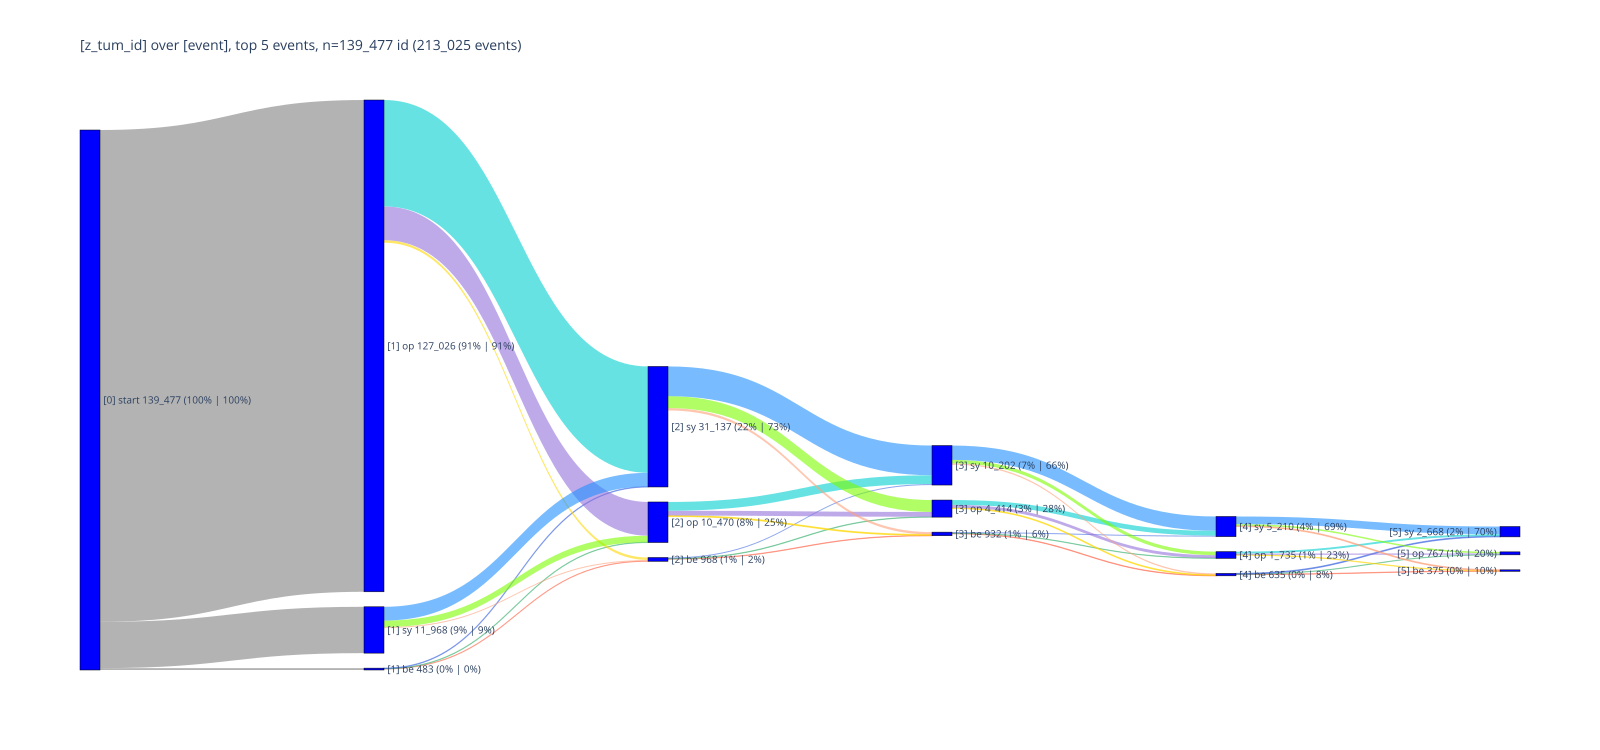

In [32]:
_filters_track = [
    FILTERS_DY,
    FILTERS_C18,
    FILTERS_HAS_TREAT,
]

_filter_track=hlp.get_duckdb_filter_n(
    con=con,
    query="""--sql
        from Tumor
        """,
    filters=_filters_track,
    # distinct_metric="z_tum_id",
    first_n_filter_apply_to_rows=2,
)

# _filter = f"""--sql
#     {FILTER_DEFAULT}
#     and z_icd10_3d in ('C18')
# """
db_sankey = con.sql(f"""--sql
    with t1 as (
        select  t.z_tum_id
                ,op.Datum_OP as date_op
                ,Datum_Beginn_SYST as date_sy
                ,Datum_Beginn_Bestrahlung as date_be
        from    Tumor t
        left join OP op on t.z_tum_id = op.z_tum_id
        left join SYST sy on t.z_tum_id = sy.z_tum_id
        left join Bestrahlung be on t.z_tum_id = be.z_tum_id
        where {_filter_track}
        --where z_dy >= 2020 and year(Datum_OP) >= 2020 and year(Datum_Beginn_SYST) >= 2020 and year(Datum_Beginn_Bestrahlung) >= 2020
    ),
    t2 as (
        SELECT  *
        FROM t1
        --UNPIVOT (date FOR event IN (date_op AS 'op', date_sy AS 'sy', date_be AS 'be'))
        UNPIVOT INCLUDE NULLS (
            date -- This is the value column
            FOR event IN (
                date_op AS 'op',
                date_sy AS 'sy',
                date_be AS 'be'
            )
        )
    ),
    t3 as (
        SELECT  z_tum_id
                ,date
                ,event
        FROM t2
        -- de-duplicate
        group by z_tum_id, date, event
    )
    select * from t3
""")

# tbl.descr_db(db_sankey,"sankey")

n_tum = con.sql("""select count(distinct z_tum_id) from db_sankey""").fetchone()[0]
n_tum_date = con.sql("""select count(distinct z_tum_id) from db_sankey where date is not null""").fetchone()[0]
n_events = con.sql("""select count(*) from db_sankey""").fetchone()[0]
n_events_date = con.sql("""select count(*) from db_sankey where date is not null""").fetchone()[0]

print(f"darin {n_tum:_} Tumore, {n_events:_} deduplizierte Therapien | darin mit Datum: {n_tum_date:_} Tumore, {n_events_date:_} Therapien")

_df = db_sankey.to_df().dropna()
pls.plot_sankey(_df, max_events_per_id=5, exclude_overlap_event=False,height=750, width=1600,)

## <a id='toc1_11_'></a>[🕹️ interaktiv](#toc0_)

In [33]:
if False:
    import pygwalker as pyg

    spec = "config/pygwalker_spec_colo.json"
    nodes = [
        ("cnt_tum", "count(distinct z_tum_id)"),
        ("cnt_pat", "count(distinct z_pat_id)"),
        ("cnt_op", "count(distinct op_id)"),
        ("cnt_st", "count(distinct st_id)"),
        ("cnt_syst", "count(distinct syst_id)"),
    ]
    hlp.add_measures_to_pyg_config(spec, nodes=nodes)

    _ = pyg.walk(
        db_colon.to_df(),
        appearance=os.environ['THEME'],
        spec=spec,
        kernel_computation=True,
    )